# Proyecto Producción de Papa con IA

## 1. Importación y Preparación de Datos

In [ ]:
import pandas as pd
import numpy as np
# Cargar datos 
data = pd.read_csv('../Data/produccion_papa_clima_temperaturas_corregidas.csv',); # sep=";", encoding="latin1"
data.head()

,Año,Departamento,Area (ha),Produccion (ton),Rendimiento (ha/ton),Produccion Nacional (ton),Area Nacional (ha),temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
0,2010,ANTIOQUIA,9561.80,168730.00,17.65,5.41,5.99,23.5,2150.0,1550.0,78.0,1450.0
1,2010,BOYACA,46411.83,816434.91,17.59,26.18,29.06,17.2,1200.0,2500.0,85.0,1200.0
2,2010,CALDAS,636.00,8176.25,12.86,0.26,0.40,19.8,1800.0,2000.0,82.0,1350.0
3,2010,CASANARE,11.50,115.00,10.00,0.00,0.01,27.5,1500.0,300.0,70.0,1800.0
4,2010,CAUCA,2579.00,47636.90,18.47,1.53,1.61,21.0,2500.0,800.0,88.0,1100.0


In [6]:
data.shape

(194, 12)

### Transformación de columnas (Renombrar columnas, eliminar carácteres)

In [23]:
data = data.rename(columns=str.lower).rename(columns=lambda x: x.replace(" ", "_")).rename(columns=lambda x: x.replace(")", "")).rename(columns=lambda x: x.replace("(", "")).rename(columns=lambda x: x.replace("/", "")).rename(columns=lambda x: x.replace("ñ", "n")) #Renombrar datos y quitar espacios
data['departamento'] = data['departamento'].str.replace('NARIÑO', 'NARINO').str.replace('NORTE DE SANTANDER', 'NORTE_DE_SANTANDER').str.replace('VALLE DEL CAUCA', 'VALLE_DEL_CAUCA') # Renombrar departamentos

In [8]:
data.head()

,ano,departamento,area_ha,produccion_ton,rendimiento_haton,produccion_nacional_ton,area_nacional_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
0,2010,ANTIOQUIA,9561.80,168730.00,17.65,5.41,5.99,23.5,2150.0,1550.0,78.0,1450.0
1,2010,BOYACA,46411.83,816434.91,17.59,26.18,29.06,17.2,1200.0,2500.0,85.0,1200.0
2,2010,CALDAS,636.00,8176.25,12.86,0.26,0.40,19.8,1800.0,2000.0,82.0,1350.0
3,2010,CASANARE,11.50,115.00,10.00,0.00,0.01,27.5,1500.0,300.0,70.0,1800.0
4,2010,CAUCA,2579.00,47636.90,18.47,1.53,1.61,21.0,2500.0,800.0,88.0,1100.0


### Eliminar columnas que no son necesarias para la el modelo

In [9]:
data = data.drop(columns=['rendimiento_haton', 'produccion_nacional_ton', 'area_nacional_ha', 'produccion_ton']) # Eliminar columnas del DataFrame


In [10]:
data.head()

,ano,departamento,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
0,2010,ANTIOQUIA,9561.80,23.5,2150.0,1550.0,78.0,1450.0
1,2010,BOYACA,46411.83,17.2,1200.0,2500.0,85.0,1200.0
2,2010,CALDAS,636.00,19.8,1800.0,2000.0,82.0,1350.0
3,2010,CASANARE,11.50,27.5,1500.0,300.0,70.0,1800.0
4,2010,CAUCA,2579.00,21.0,2500.0,800.0,88.0,1100.0


### Transformación de datos object a category

In [11]:
data['departamento'] = data['departamento'].astype('category')
data['ano'] = data['ano'].astype('category')
data.departamento.dtype
data.ano.dtype # Convertir la columna 'departamento' a tipo 'category'

CategoricalDtype(categories=[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                  2020, 2021, 2022, 2023],
, ordered=False, categories_dtype=int64)

In [12]:
data.dtypes # Verificar los tipos de datos de las columnas

ano                 category
departamento        category
area_ha              float64
temperatura          float64
precipitacion        float64
altitud_mm           float64
humedad_relativa     float64
radiacion_solar      float64
dtype: object

In [13]:
data.info() # Información general del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ano               194 non-null    category
 1   departamento      194 non-null    category
 2   area_ha           194 non-null    float64 
 3   temperatura       194 non-null    float64 
 4   precipitacion     194 non-null    float64 
 5   altitud_mm        194 non-null    float64 
 6   humedad_relativa  194 non-null    float64 
 7   radiacion_solar   194 non-null    float64 
dtypes: category(2), float64(6)
memory usage: 10.9 KB


## 2. Imputación de Datos (Este paso no se aplicó debido a que el dataframe no tiene valores nulos)

In [14]:
data.isnull().sum() # Verificar si hay valores nulos en el DataFrame

ano                 0
departamento        0
area_ha             0
temperatura         0
precipitacion       0
altitud_mm          0
humedad_relativa    0
radiacion_solar     0
dtype: int64

### Creación de variables cuantitativas y cualitativas

In [15]:
columnas_cuantitativas = data.select_dtypes(include=['number']).columns
columnas_cualitativas = data.select_dtypes(include=['category']).columns

In [16]:
print(columnas_cualitativas)
print(columnas_cuantitativas)

Index(['ano', 'departamento'], dtype='object')
Index(['area_ha', 'temperatura', 'precipitacion', 'altitud_mm',
       'humedad_relativa', 'radiacion_solar'],
      dtype='object')


### Filtros (Para conocer el comportamiento de los datos)

In [17]:
filtro = (data['temperatura'] > 12) & (data['temperatura'] < 20)

In [18]:
data[filtro].head() # Aplicar filtro para mostrar datos donde la temperatura está entre 12 y 20 grados

,ano,departamento,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
1,2010,BOYACA,46411.83,17.2,1200.0,2500.0,85.0,1200.0
2,2010,CALDAS,636.00,19.8,1800.0,2000.0,82.0,1350.0
5,2010,CUNDINAMARCA,58817.21,15.5,1100.0,2600.0,80.0,1250.0
7,2010,NARINO,31087.39,17.8,1650.0,2320.0,85.0,1444.0
10,2010,QUINDIO,14.00,19.5,1900.0,1800.0,80.0,1300.0


In [279]:
a=data.produccion_ton.max()
a = data[data['produccion_ton'] == a].iloc[0] # Obtener la fila con la producción máxima
print(a.departamento, a.ano, a.produccion_ton)


CUNDINAMARCA 2021 2719396.84


In [415]:
data.iloc[0:5, 0:3] # Seleccionar las primeras 5 filas y las primeras 3 columnas

,ano,departamento,area_ha
0,2010,ANTIOQUIA,9561.80
1,2010,BOYACA,46411.83
2,2010,CALDAS,636.00
3,2010,CASANARE,11.50
4,2010,CAUCA,2579.00


In [416]:
data.loc[:, ['departamento', 'temperatura']].head() # Seleccionar columnas específicas

,departamento,temperatura
0,ANTIOQUIA,23.5
1,BOYACA,17.2
2,CALDAS,19.8
3,CASANARE,27.5
4,CAUCA,21.0


In [282]:
filtra_data = data.loc[data['departamento'] == 'NARIÑO', ['departamento', 'temperatura','produccion_ton']] #PARA FILTRAR POR DEPARTAMENTO Y SELECCIONAR COLUMNAS ESPECÍFICAS

In [284]:
filtra_data.head()

,departamento,temperatura,produccion_ton
7,NARIÑO,17.8,556085.08
22,NARIÑO,18.2,531593.68
38,NARIÑO,18.5,570807.60
52,NARIÑO,17.9,505827.10
66,NARIÑO,18.0,496974.60


In [286]:
# Filtrar departamentos NARIÑO, CUNDINAMARCA Y BOYACA
filtra_data = data.loc[data['departamento'].isin(['NARIÑO', 'CUNDINAMARCA', 'BOYACA']), ['departamento', 'temperatura','produccion_ton','altitud_mm', 'precipitacion', 'humedad_relativa','radiacion_solar']] # Filtrar por departamentos específicos y seleccionar columnas

In [287]:
print(filtra_data)

     departamento  temperatura  produccion_ton  altitud_mm  precipitacion  \
1          BOYACA         17.2       816434.91      2500.0         1200.0   
5    CUNDINAMARCA         15.5      1319947.39      2600.0         1100.0   
7          NARIÑO         17.8       556085.08      2320.0         1650.0   
15         BOYACA         17.5       746304.98      2530.0         1250.0   
20   CUNDINAMARCA         15.8      1253419.66      2630.0         1150.0   
22         NARIÑO         18.2       531593.68      2324.0         1400.0   
30         BOYACA         17.0       734951.58      2480.0         1180.0   
35   CUNDINAMARCA         16.0      1135531.50      2580.0         1080.0   
38         NARIÑO         18.5       570807.60      2350.0         1750.0   
46         BOYACA         17.3       733224.56      2510.0         1220.0   
49   CUNDINAMARCA         15.7      1075489.47      2610.0         1120.0   
52         NARIÑO         17.9       505827.10      2345.0         1300.0   

## 3. Estandarización (Normalización y Dummies)

### Normalización datos cuantitativos

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#Normalización
scaler = MinMaxScaler()
data_normalized = data.copy()

data_normalized[
    columnas_cuantitativas.tolist()
] = scaler.fit_transform(data[
    columnas_cuantitativas.tolist()
    ]
                            ) # Normalizar las columnas cuantitativas utilizando MinMaxScaler

In [25]:
data_normalized.describe() # Descripción estadística de las columnas cuantitativas

,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,0.097672,0.501317,0.296867,0.494231,0.417468,0.446883
std,0.170458,0.248322,0.211734,0.300021,0.250173,0.242886
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000393,0.321168,0.165686,0.278431,0.222222,0.268293
50%,0.018587,0.598540,0.254902,0.437255,0.372222,0.475610
75%,0.072043,0.649635,0.344118,0.748039,0.592593,0.609756
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dummies datos cualitativos

In [26]:
data_normalized = pd.get_dummies(data_normalized, dtype= 'int64', columns=columnas_cualitativas.tolist()) # Convertir las columnas cualitativas en variables dummy

In [27]:
data_normalized.describe() # Estadísticas descriptivas de las columnas numéricas

,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar,ano_2010,ano_2011,ano_2012,ano_2013,...,departamento_CUNDINAMARCA,departamento_HUILA,departamento_META,departamento_NARINO,departamento_NORTE_DE_SANTANDER,departamento_PUTUMAYO,departamento_QUINDIO,departamento_SANTANDER,departamento_TOLIMA,departamento_VALLE_DEL_CAUCA
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,...,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,0.097672,0.501317,0.296867,0.494231,0.417468,0.446883,0.072165,0.077320,0.082474,0.072165,...,0.072165,0.072165,0.020619,0.072165,0.072165,0.067010,0.041237,0.072165,0.072165,0.072165
std,0.170458,0.248322,0.211734,0.300021,0.250173,0.242886,0.259430,0.267789,0.275798,0.259430,...,0.259430,0.259430,0.142471,0.259430,0.259430,0.250687,0.199353,0.259430,0.259430,0.259430
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000393,0.321168,0.165686,0.278431,0.222222,0.268293,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.018587,0.598540,0.254902,0.437255,0.372222,0.475610,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.072043,0.649635,0.344118,0.748039,0.592593,0.609756,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
data_normalized.shape # Verificar la forma del DataFrame normalizado

(194, 36)

## 4. Métricas de evaluación para determinar clústers

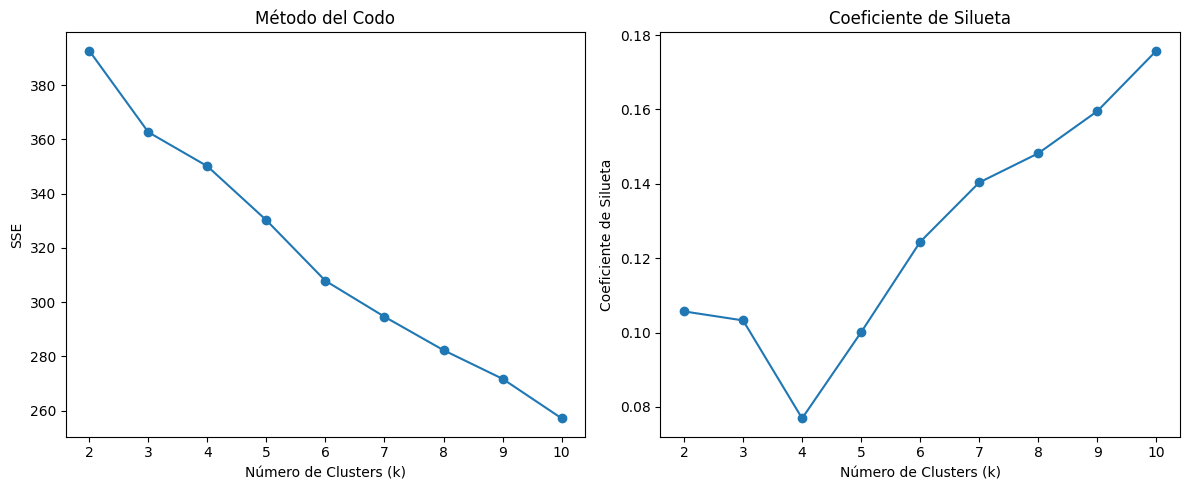

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Determinar el mejor número de clusters (k) usando el método del codo y el coeficiente de silueta
def determinar_mejor_k(data, max_k=10):
    sse = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=0)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)
        silhouette_avg = silhouette_score(data, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)
    
    # Graficar el método del codo
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(k_range, sse, marker='o')
    plt.title('Método del Codo')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('SSE')
    
    # Graficar el coeficiente de silueta
    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.title('Coeficiente de Silueta')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Coeficiente de Silueta')
    
    plt.tight_layout()
    plt.show()

# Llamar a la función para determinar el mejor k
determinar_mejor_k(data_normalized)


### Mapa de correlación (Mapa de calor)

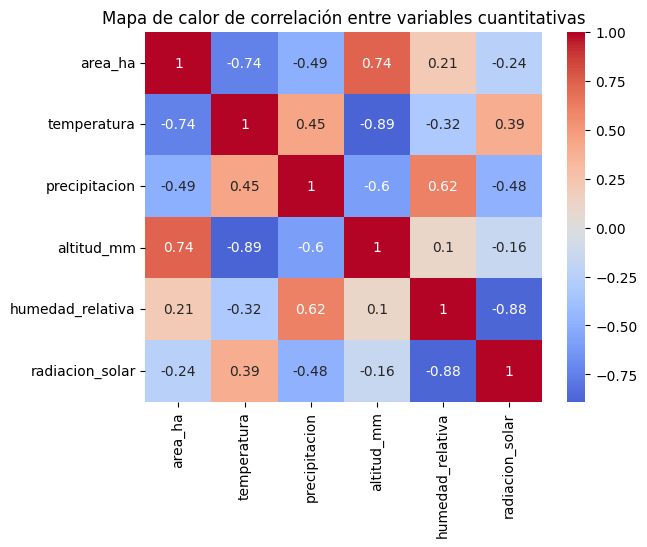

In [30]:
import seaborn as sns
matrix = data_normalized[columnas_cuantitativas].corr()
sns.heatmap(matrix, annot=True, cmap='coolwarm', center = 0)
plt.title('Mapa de calor de correlación entre variables cuantitativas')
plt.show()  

### Mapa de correlación variables con más afinidad

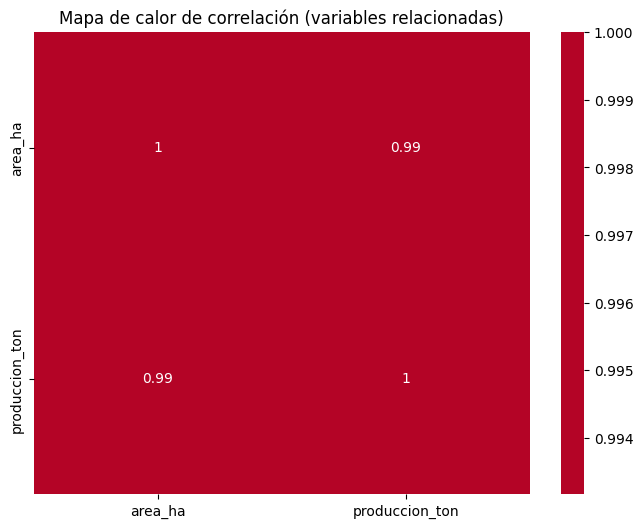

In [295]:
# Seleccionar las variables con mayor relación entre sí
variables_relacionadas = [
    'area_ha', 'produccion_ton'
]

# Visualización: Mapa de calor de correlación entre las variables seleccionadas
import matplotlib.pyplot as plt

corr_matrix_rel = data[variables_relacionadas].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_rel, annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de calor de correlación (variables relacionadas)')
plt.show()

### Visualización de clústeres con PCA

## 5. Modelo no supervisado (K-MEANS)

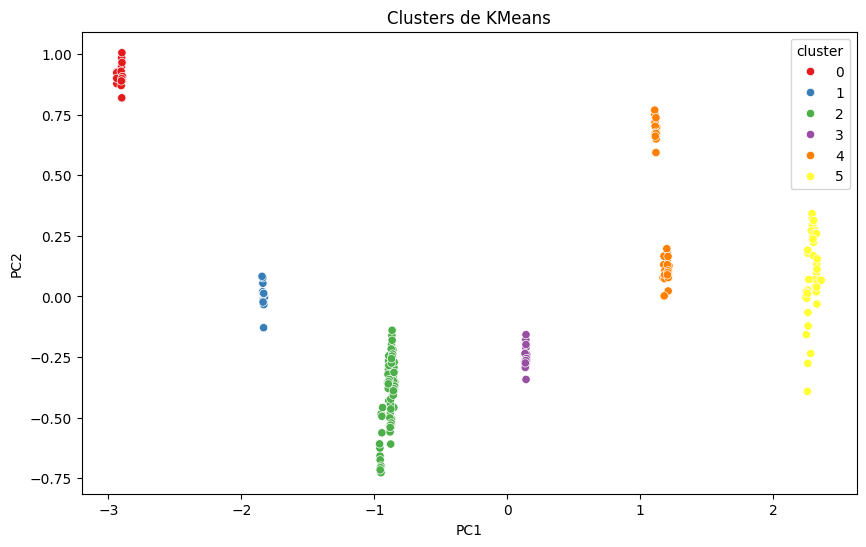

In [31]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

data_normalized_clusters = data_normalized.copy() # Crear una copia del DataFrame normalizado para trabajar con los clusters
data_cluster = data.copy() # Crear una copia del DataFrame original para trabajar con los clusters
# Modelo no supervisado
kmeans = KMeans(n_clusters=6, random_state=0) # Crear un modelo KMeans con 3 clusters
data_cluster['cluster'] = -1 # Ajustar el modelo y predecir los clusters

clusters = kmeans.fit_predict(data_normalized_clusters) # Ajustar el modelo y predecir los clusters
data_cluster.loc[data.index, 'cluster'] = clusters # Asignar los clusters al DataFrame original
data_normalized_clusters['cluster'] = clusters # Asignar los clusters al DataFrame normalizado

#visualización de clusters
pca = PCA(n_components=2) # Reducir la dimensionalidad a 2 componentes principales
X_pca = pca.fit_transform(data_normalized_clusters)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='Set1')
plt.title('Clusters de KMeans')
plt.show()


In [32]:
data_normalized_clusters.head() # Verificar el DataFrame normalizado con los clusters añadidos

,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar,ano_2010,ano_2011,ano_2012,ano_2013,...,departamento_HUILA,departamento_META,departamento_NARINO,departamento_NORTE_DE_SANTANDER,departamento_PUTUMAYO,departamento_QUINDIO,departamento_SANTANDER,departamento_TOLIMA,departamento_VALLE_DEL_CAUCA,cluster
0,0.077660,0.598540,0.431373,0.568627,0.370370,0.524390,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.376952,0.138686,0.058824,0.941176,0.629630,0.219512,1,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,0.005166,0.328467,0.294118,0.745098,0.518519,0.402439,1,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0.000093,0.890511,0.176471,0.078431,0.074074,0.951220,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,0.020946,0.416058,0.568627,0.274510,0.740741,0.097561,1,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [33]:
data_cluster.cluster.value_counts() # Verificar la distribución de los clusters en el DataFrame original

cluster
2    70
5    42
4    36
0    18
1    14
3    14
Name: count, dtype: int64

In [35]:
departamentos_cluster_1 = data_cluster.loc[data_cluster['cluster'] == 5, [ 'departamento', 'temperatura', 'precipitacion']]
print(departamentos_cluster_1)

     departamento  temperatura  precipitacion
1          BOYACA         17.2         1200.0
5    CUNDINAMARCA         15.5         1100.0
7          NARINO         17.8         1650.0
15         BOYACA         17.5         1250.0
20   CUNDINAMARCA         15.8         1150.0
22         NARINO         18.2         1400.0
30         BOYACA         17.0         1180.0
35   CUNDINAMARCA         16.0         1080.0
38         NARINO         18.5         1750.0
46         BOYACA         17.3         1220.0
49   CUNDINAMARCA         15.7         1120.0
52         NARINO         17.9         1300.0
60         BOYACA         17.1         1280.0
63   CUNDINAMARCA         15.8         1180.0
66         NARINO         18.0         1900.0
73         BOYACA         17.6         1150.0
76   CUNDINAMARCA         16.2         1050.0
79         NARINO         18.6         1100.0
87         BOYACA         17.4         1230.0
92   CUNDINAMARCA         15.4         1130.0
94         NARINO         17.7    

## 6. Visualizaciones con diferentes técnicas

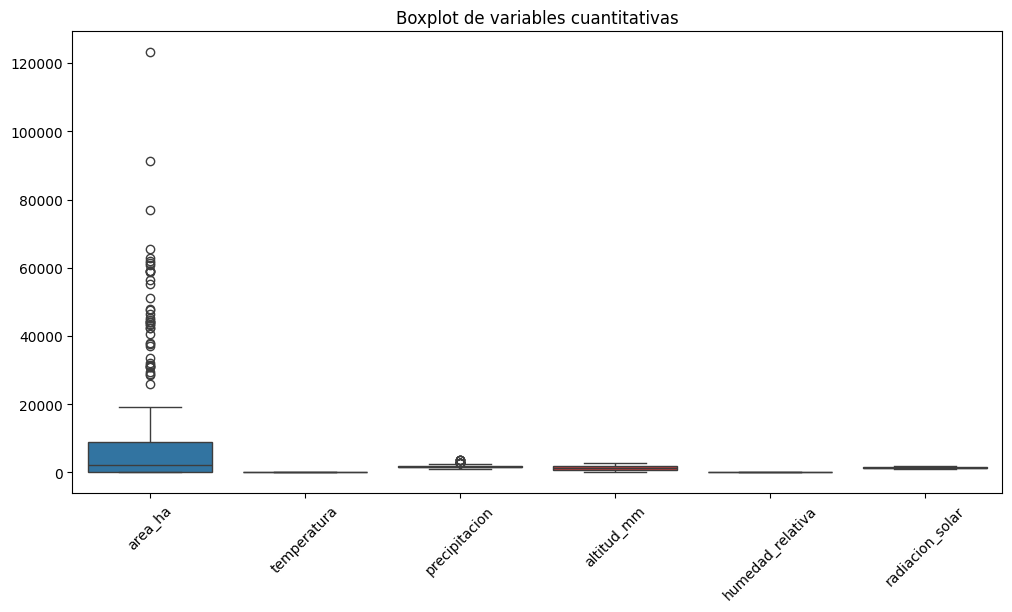

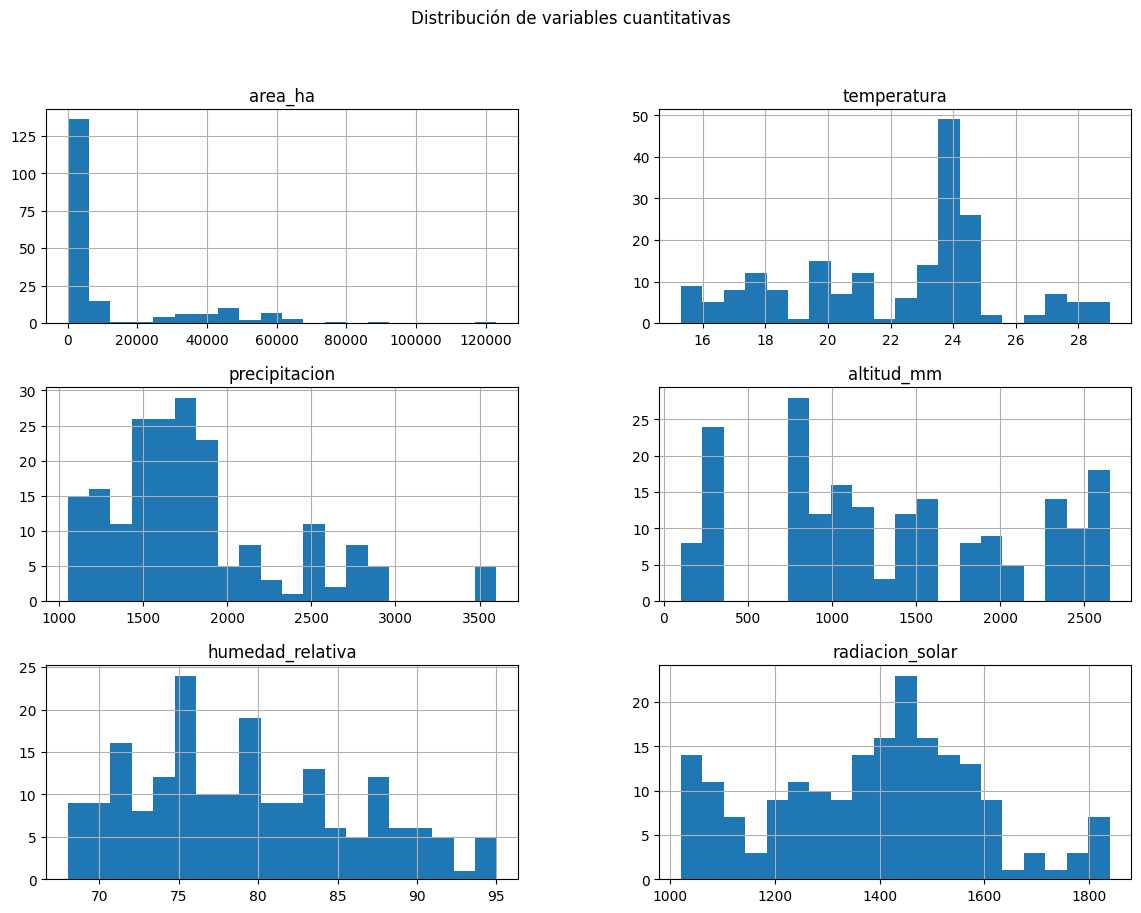

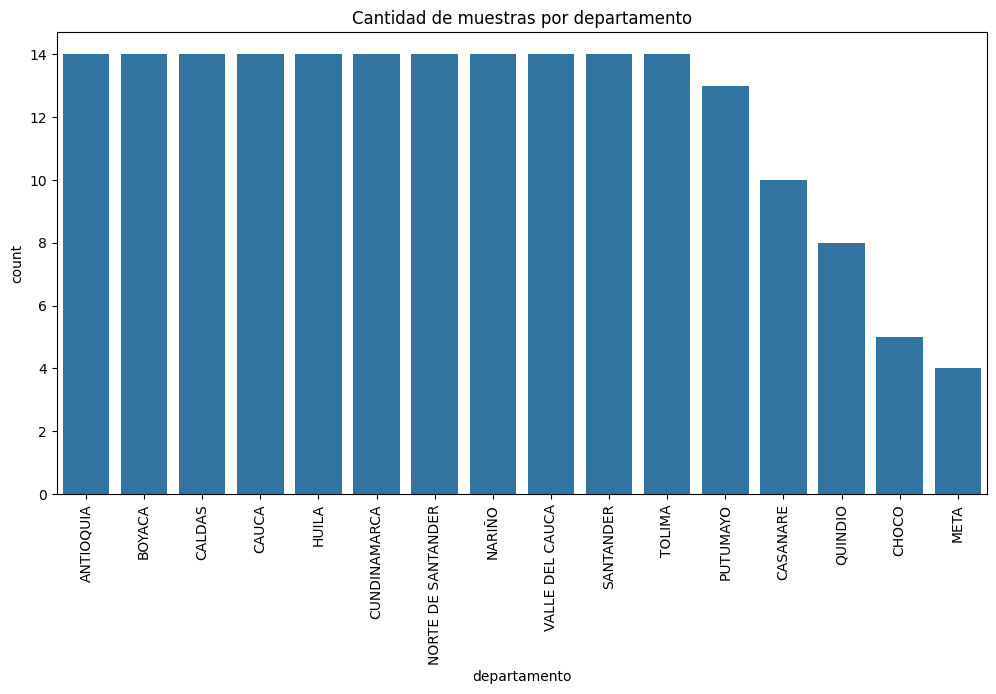

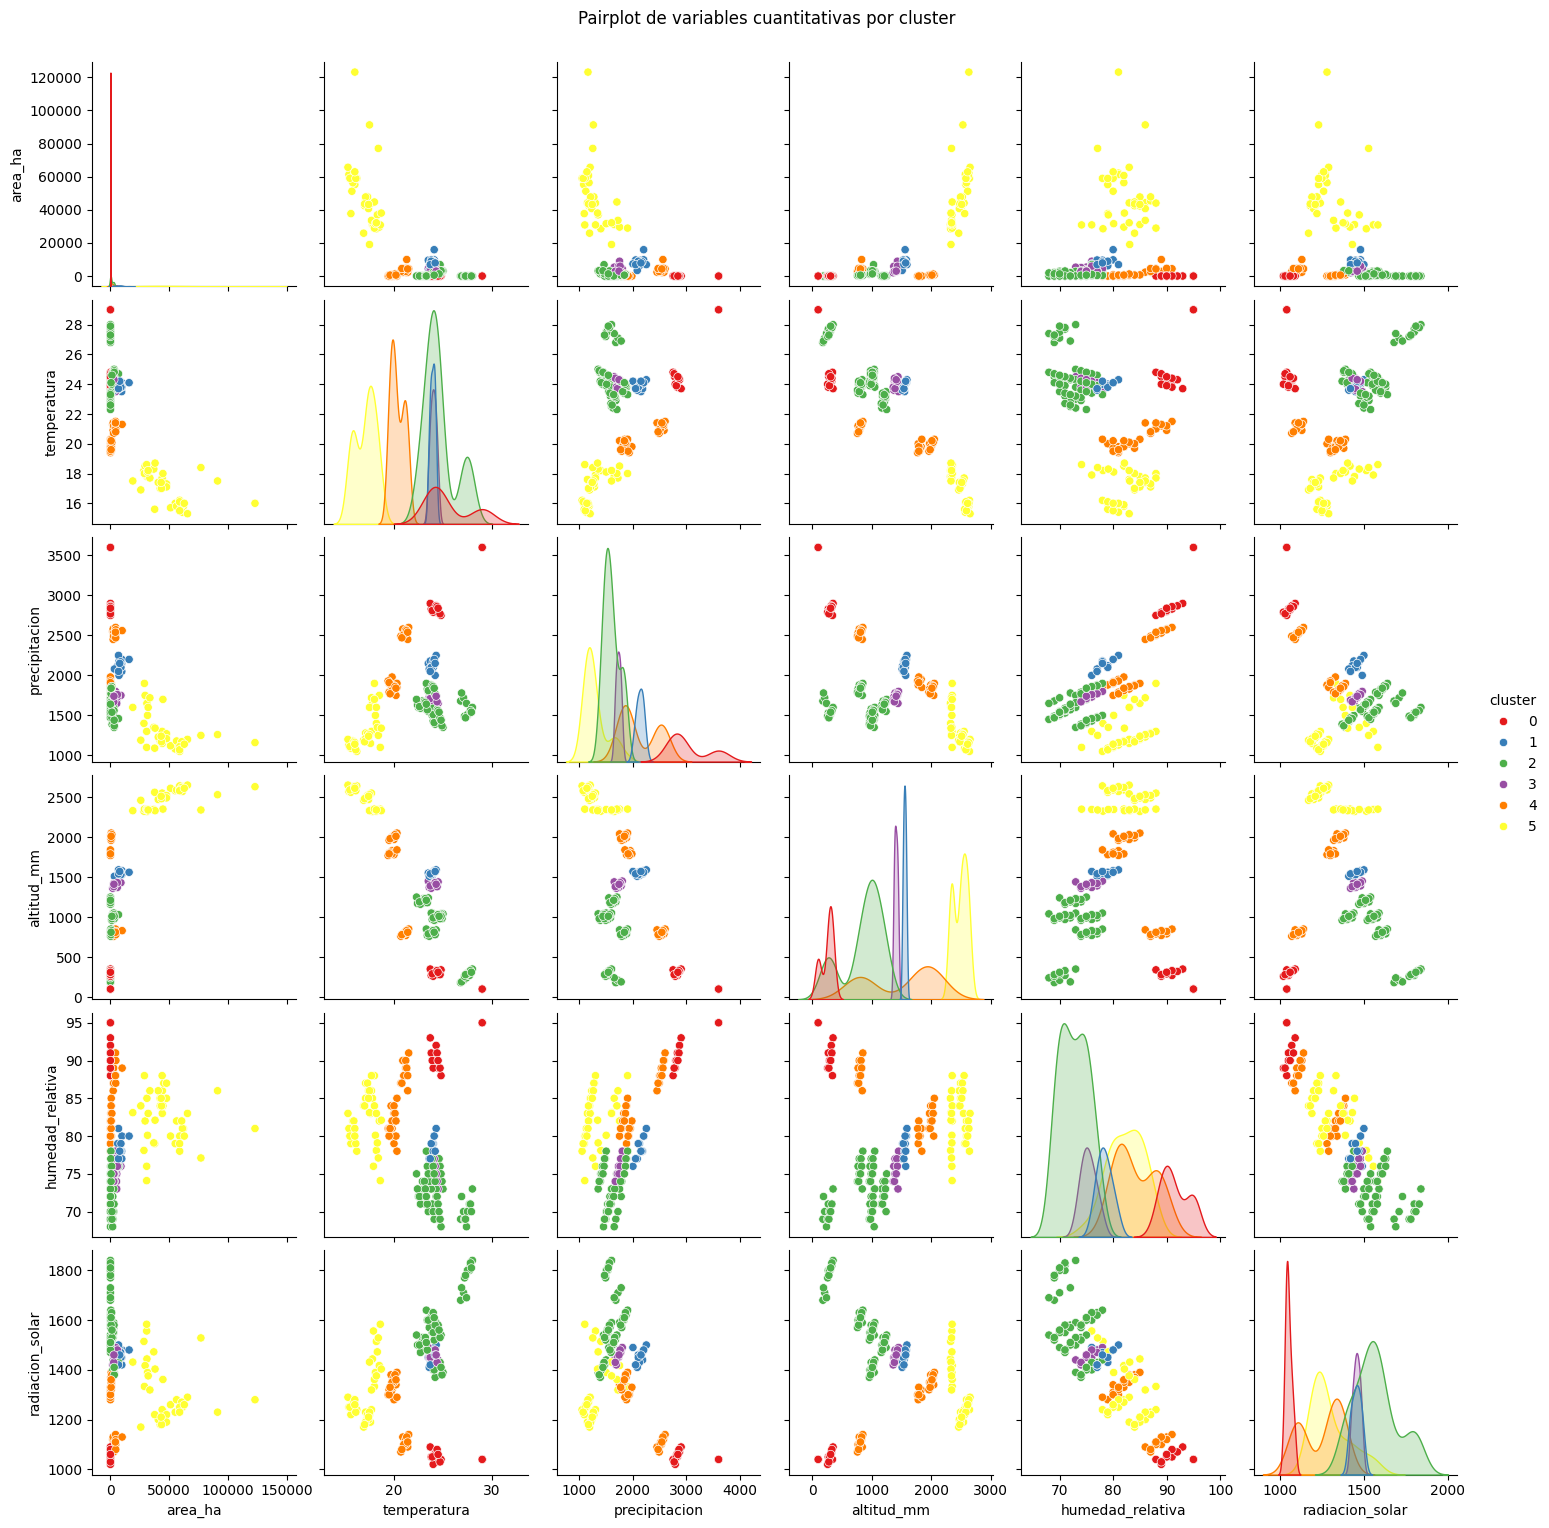

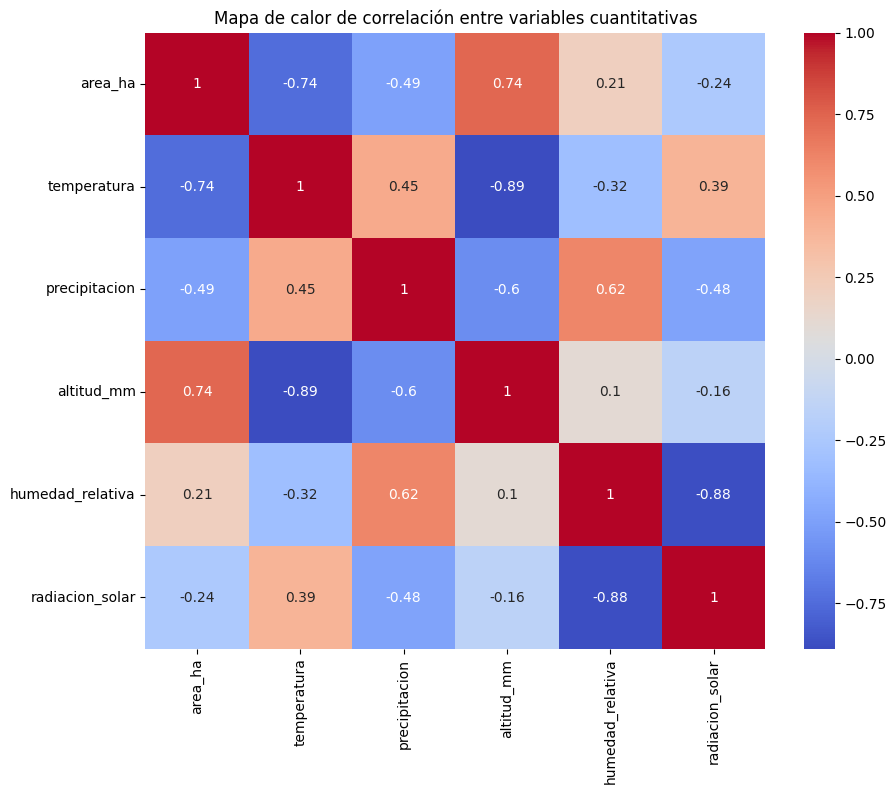

In [385]:
import seaborn as sns
from pandas.plotting import radviz, andrews_curves

import matplotlib.pyplot as plt

# Boxplot de variables cuantitativas
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[columnas_cuantitativas])
plt.title('Boxplot de variables cuantitativas')
plt.xticks(rotation=45)
plt.show()

# Gráficos de distribución (histogramas)
data[columnas_cuantitativas].hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribución de variables cuantitativas')
plt.show()

# Gráfico de barras para la cantidad de muestras por departamento
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='departamento', order=data['departamento'].value_counts().index)
plt.title('Cantidad de muestras por departamento')
plt.xticks(rotation=90)
plt.show()


# Sugerencias adicionales:
# 1. Pairplot para ver relaciones entre variables cuantitativas y clusters
sns.pairplot(data_cluster, vars=columnas_cuantitativas, hue='cluster', palette='Set1')
plt.suptitle('Pairplot de variables cuantitativas por cluster', y=1.02)
plt.show()

# 2. Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data[columnas_cuantitativas].corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación entre variables cuantitativas')
plt.show()

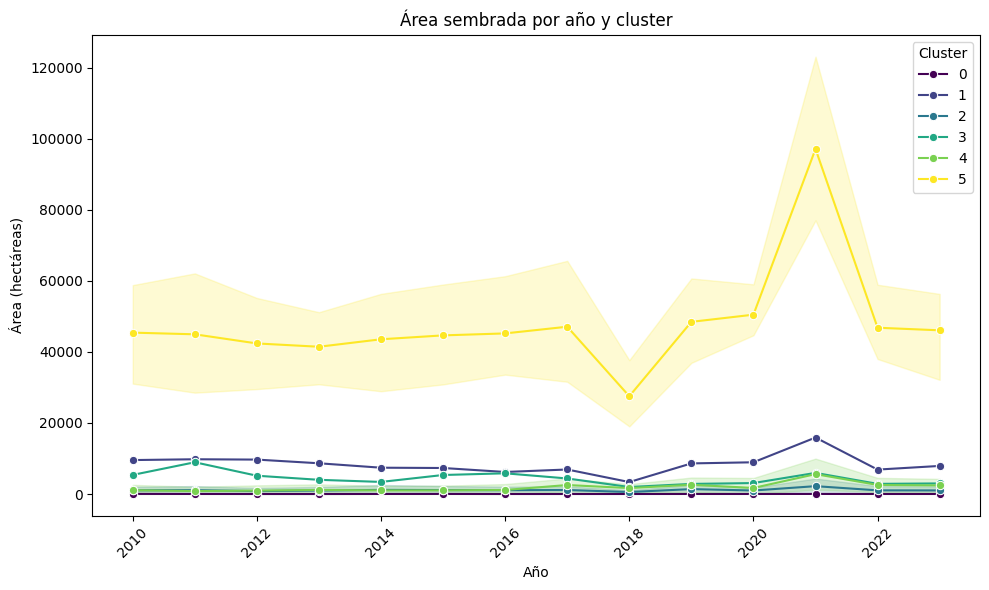

In [390]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=data_cluster, x='ano', y='area_ha', hue='cluster', marker='o', palette='viridis')
plt.title('Área sembrada por año y cluster')
plt.xlabel('Año')   
plt.ylabel('Área (hectáreas)')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

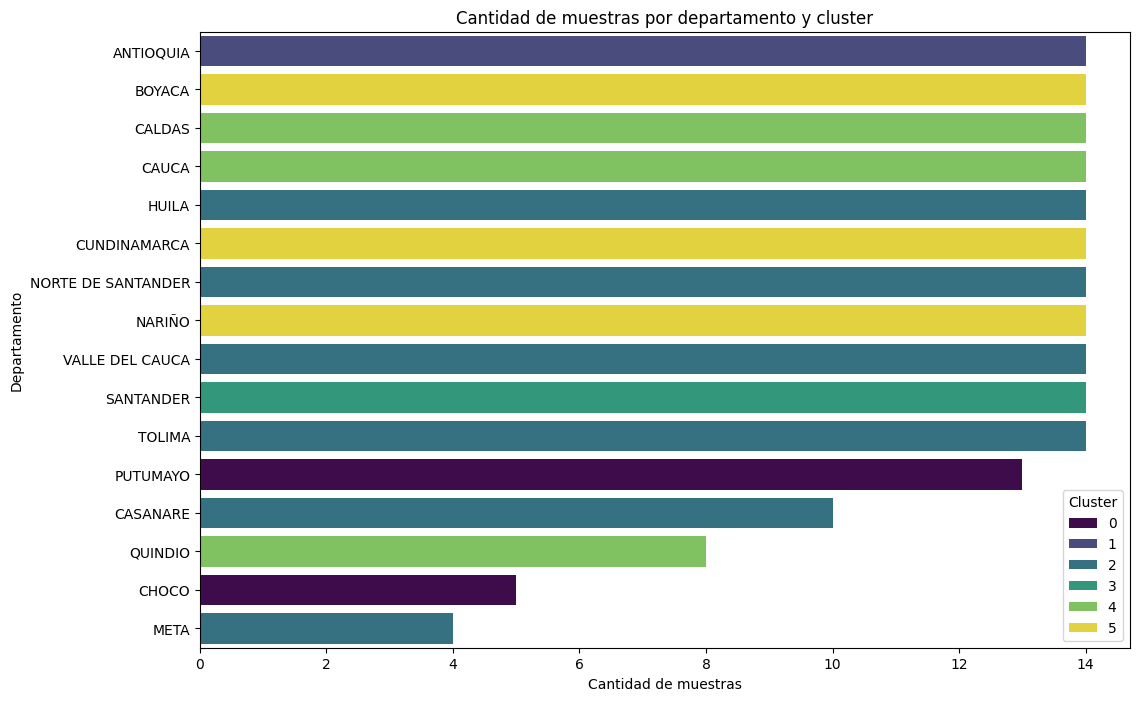

In [391]:
plt.figure(figsize=(12, 8))
sns.countplot(data=data_cluster, y='departamento', hue='cluster', palette='viridis', order=data['departamento'].value_counts().index)
plt.title('Cantidad de muestras por departamento y cluster')
plt.xlabel('Cantidad de muestras')
plt.ylabel('Departamento')
plt.legend(title='Cluster')
plt.show()

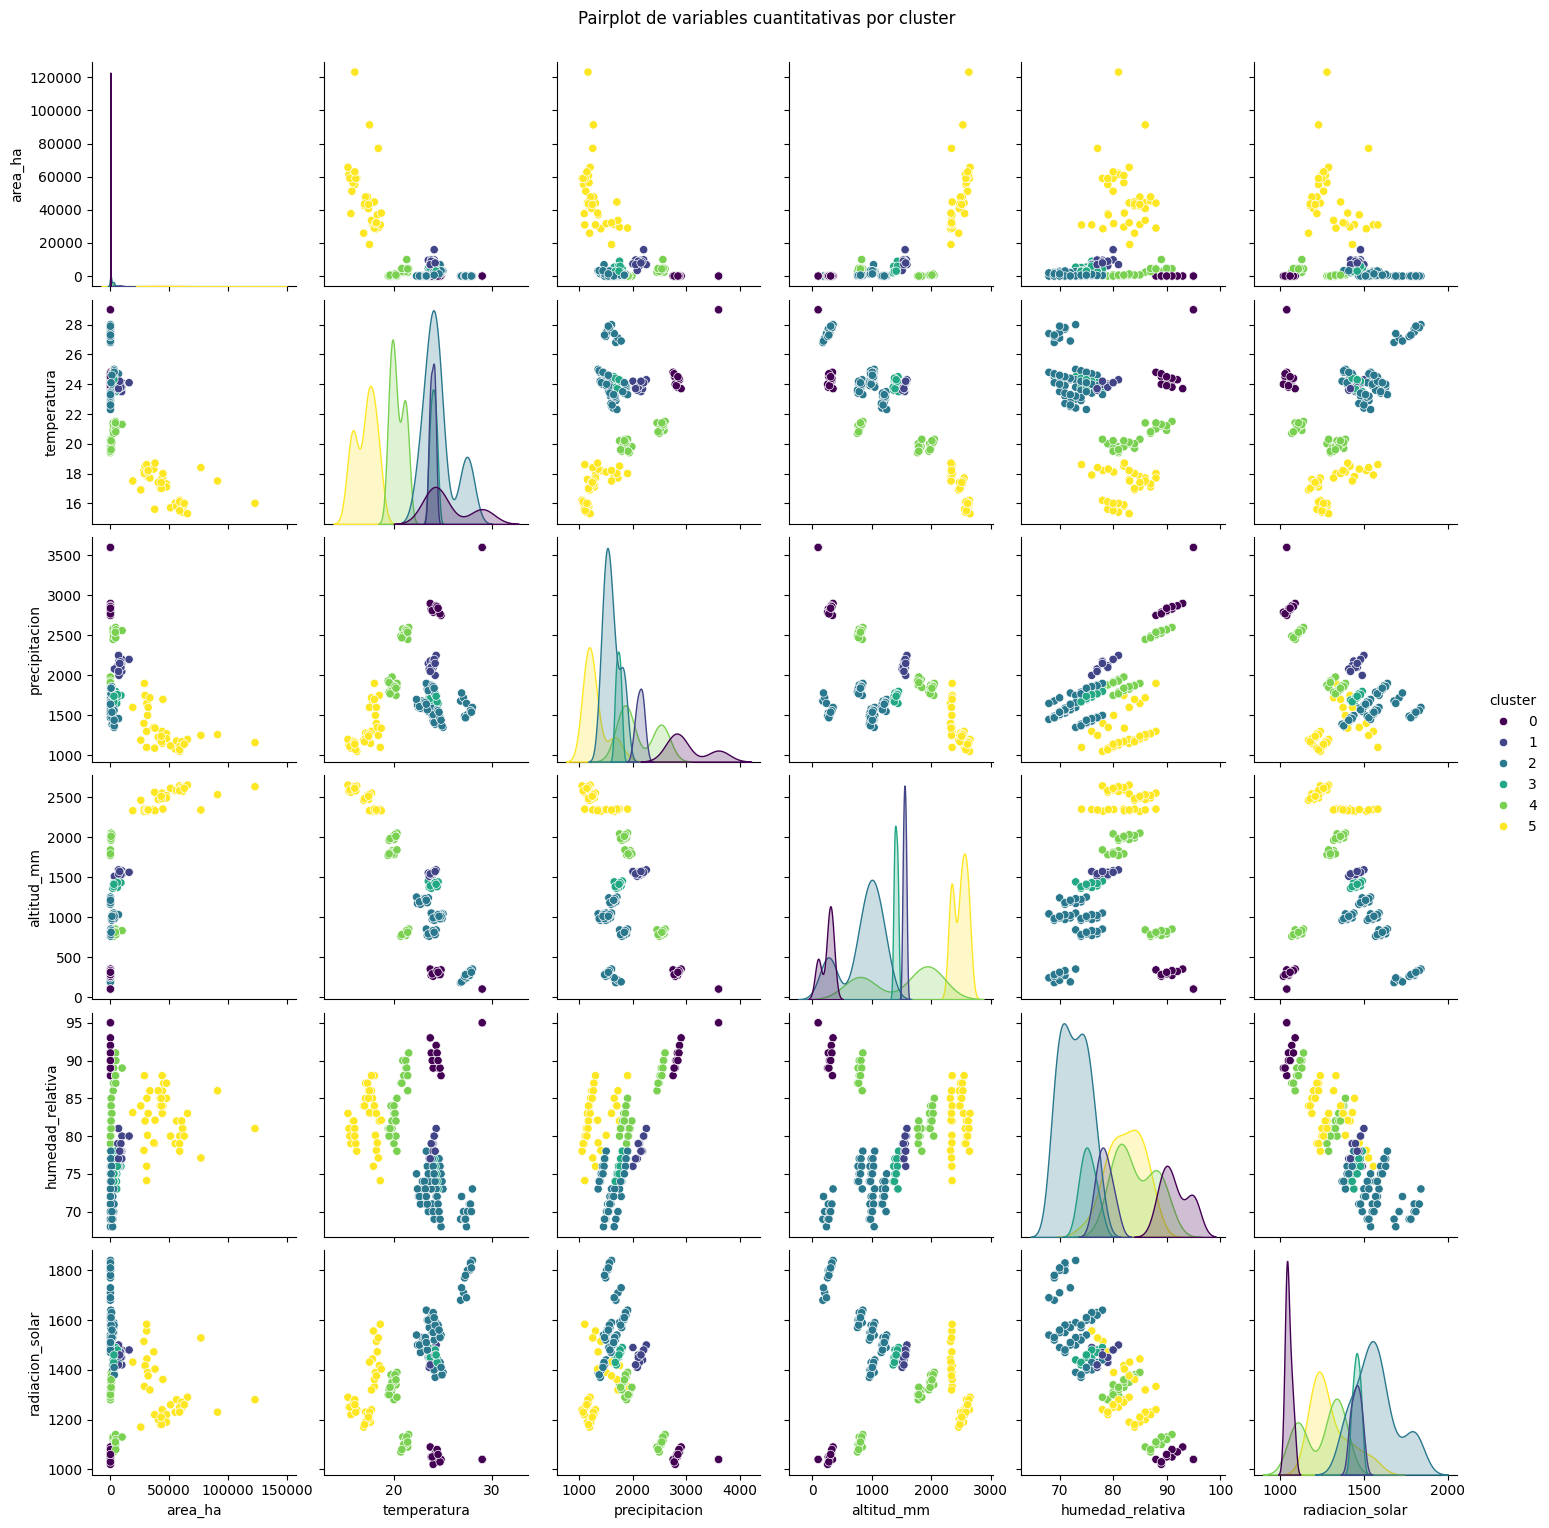

In [392]:
sns.pairplot(data_cluster, hue='cluster', vars=columnas_cuantitativas, palette='viridis')
plt.suptitle('Pairplot de variables cuantitativas por cluster', y=1.02)
plt.show()

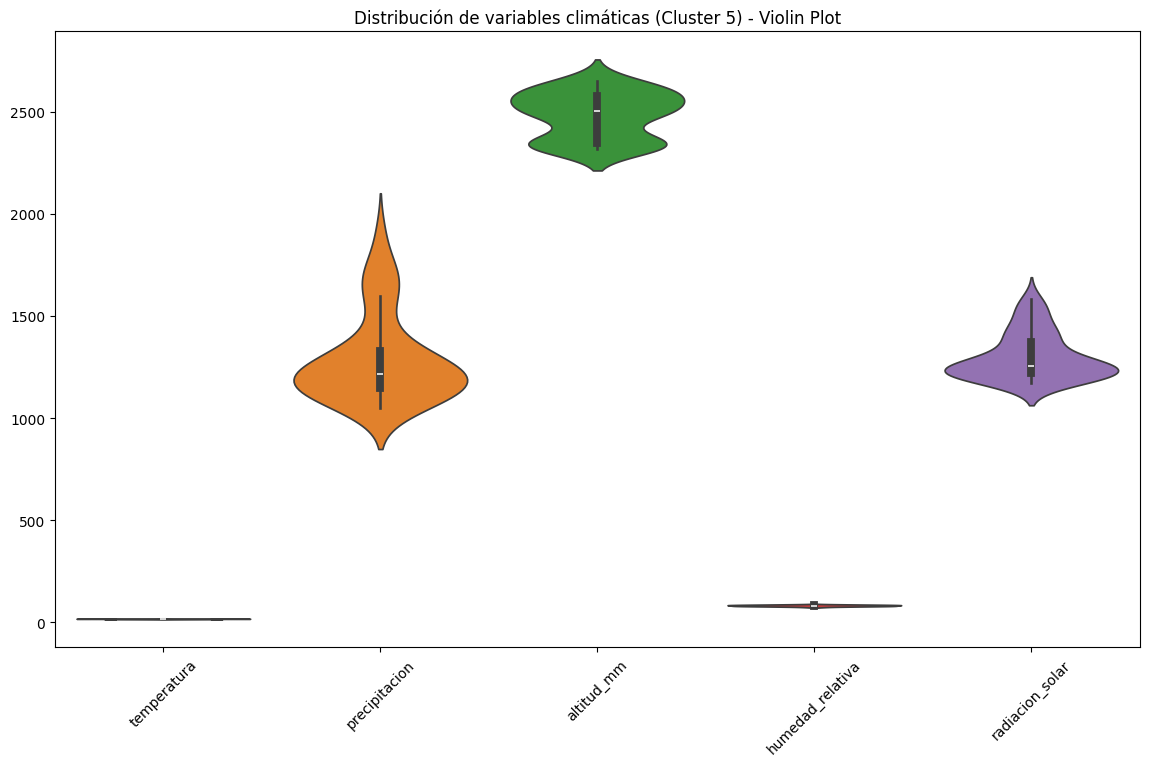

In [396]:
# Filtrar los datos de los departamentos que pertenecen al cluster 2
data_cluster_2 = data_cluster[data_cluster['cluster'] == 5]

# Seleccionar solo las columnas climáticas relevantes
columnas_climaticas = ['temperatura', 'precipitacion', 'altitud_mm', 'humedad_relativa', 'radiacion_solar']
plt.figure(figsize=(14, 8))
sns.violinplot(data=data_cluster_2[columnas_climaticas])
plt.title('Distribución de variables climáticas (Cluster 5) - Violin Plot')
plt.xticks(rotation=45)
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\2215380555.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=data_cluster, x='ano', y='rendimiento_haton', estimator='mean', ci=95)


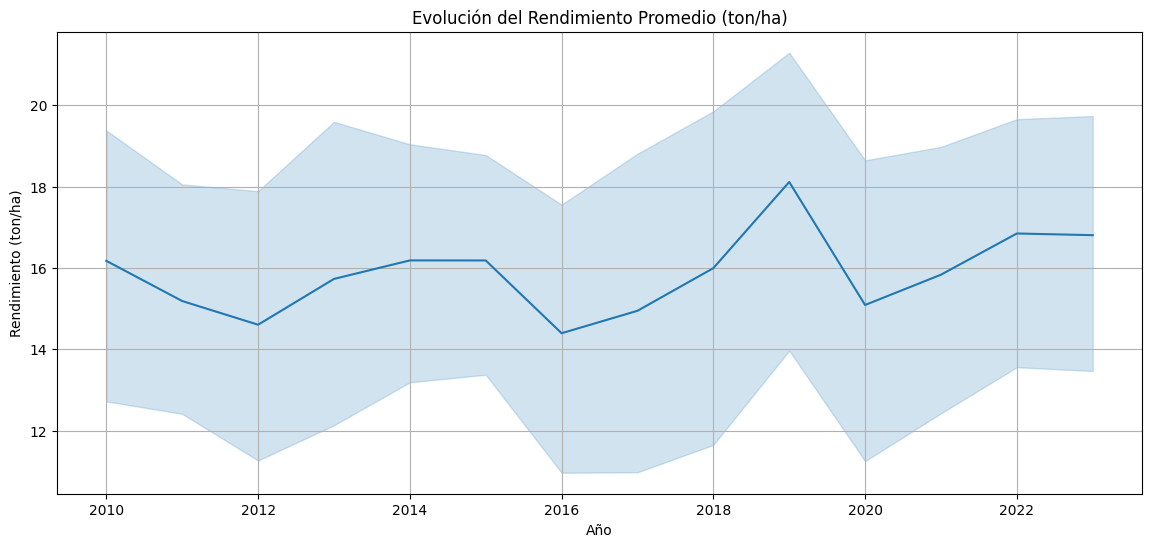

In [94]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=data_cluster, x='ano', y='rendimiento_haton', estimator='mean', ci=95)
plt.title('Evolución del Rendimiento Promedio (ton/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.xlabel('Año')
plt.grid(True)
plt.show()

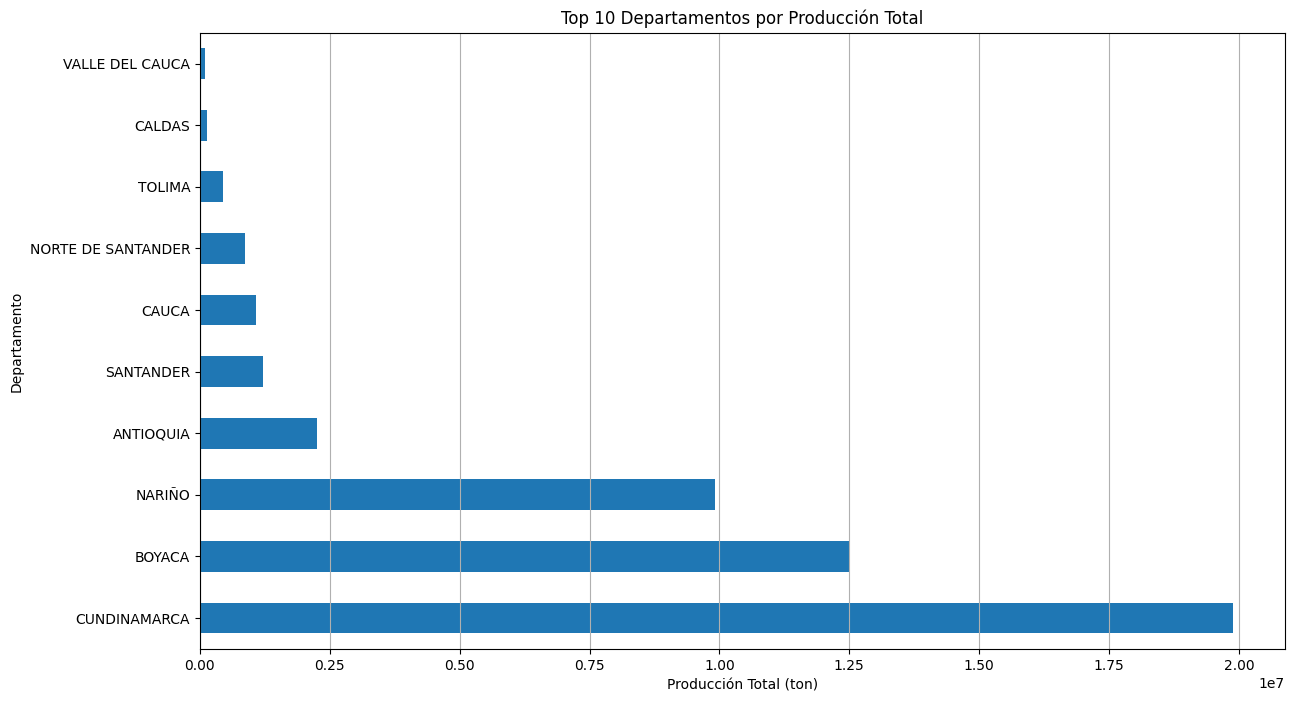

In [95]:
# Producción por Departamento (Top 10)
plt.figure(figsize=(14, 8))
data.groupby('departamento')['produccion_ton'].sum().nlargest(10).plot(kind='barh')
plt.title('Top 10 Departamentos por Producción Total')
plt.xlabel('Producción Total (ton)')
plt.ylabel('Departamento')
plt.grid(axis='x')
plt.show()

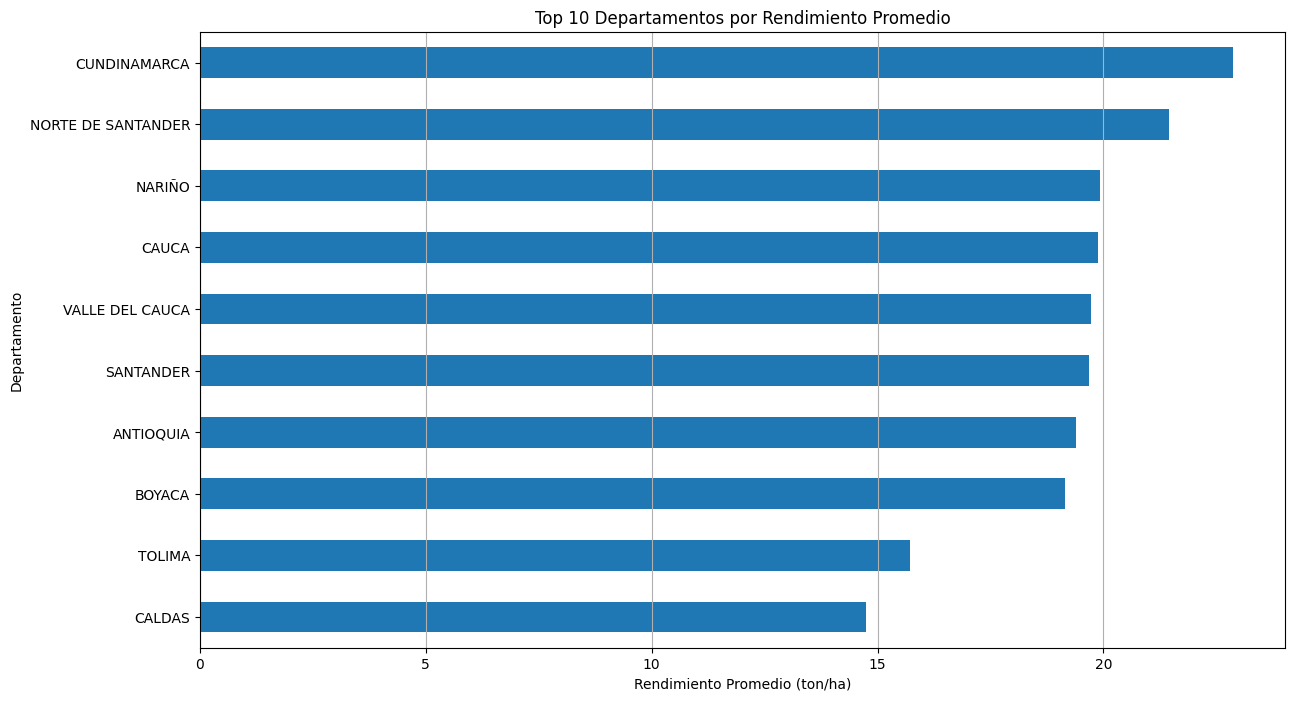

In [96]:
# Rendimiento por Departamento
plt.figure(figsize=(14, 8))
data.groupby('departamento')['rendimiento_haton'].mean().sort_values().tail(10).plot(kind='barh')
plt.title('Top 10 Departamentos por Rendimiento Promedio')
plt.xlabel('Rendimiento Promedio (ton/ha)')
plt.ylabel('Departamento')
plt.grid(axis='x')
plt.show()

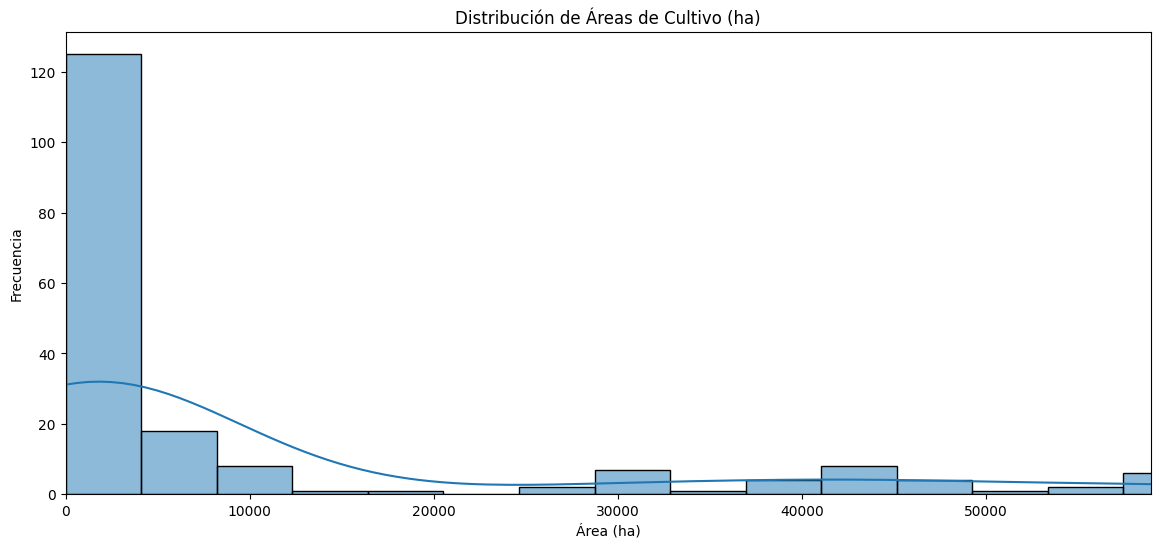

In [97]:
# Distribución de Áreas de Cultivo
plt.figure(figsize=(14, 6))
sns.histplot(data=data, x='area_ha', bins=30, kde=True)
plt.title('Distribución de Áreas de Cultivo (ha)')
plt.xlabel('Área (ha)')
plt.ylabel('Frecuencia')
plt.xlim(0, data['area_ha'].quantile(0.95))  # Excluir outliers extremos
plt.show()

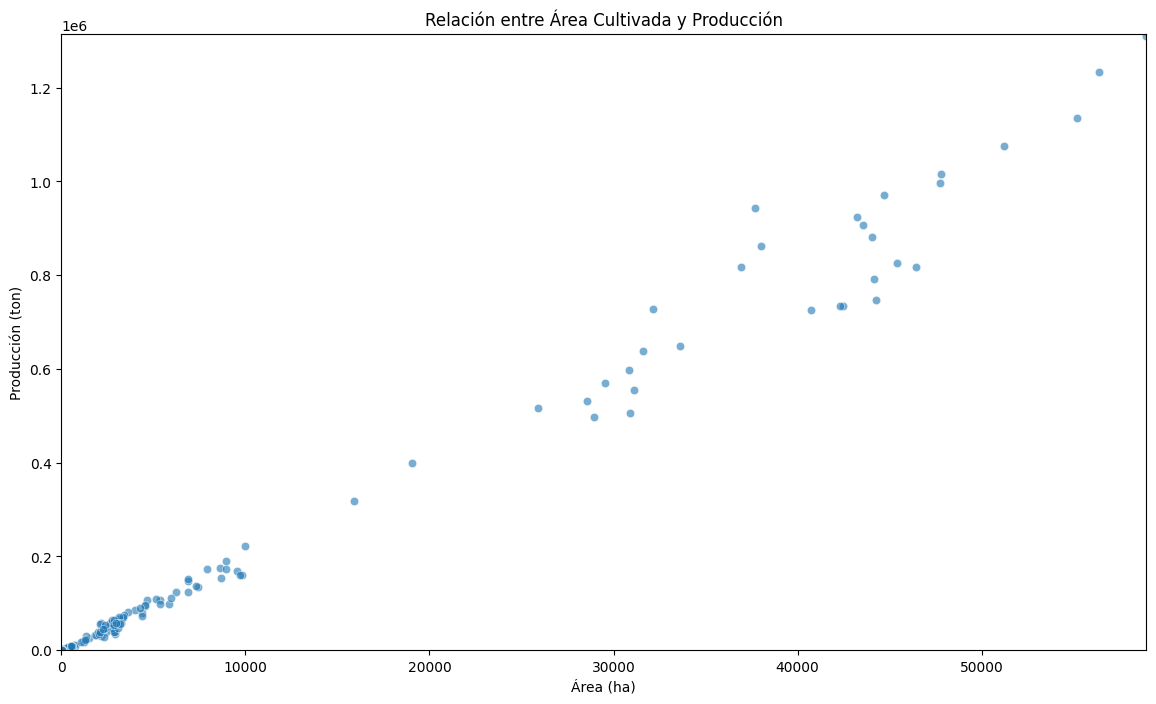

In [98]:
# Relación Área vs Producción
plt.figure(figsize=(14, 8))
sns.scatterplot(data=data, x='area_ha', y='produccion_ton', alpha=0.6)
plt.title('Relación entre Área Cultivada y Producción')
plt.xlabel('Área (ha)')
plt.ylabel('Producción (ton)')
plt.xlim(0, data['area_ha'].quantile(0.95))
plt.ylim(0, data['produccion_ton'].quantile(0.95))
plt.show()

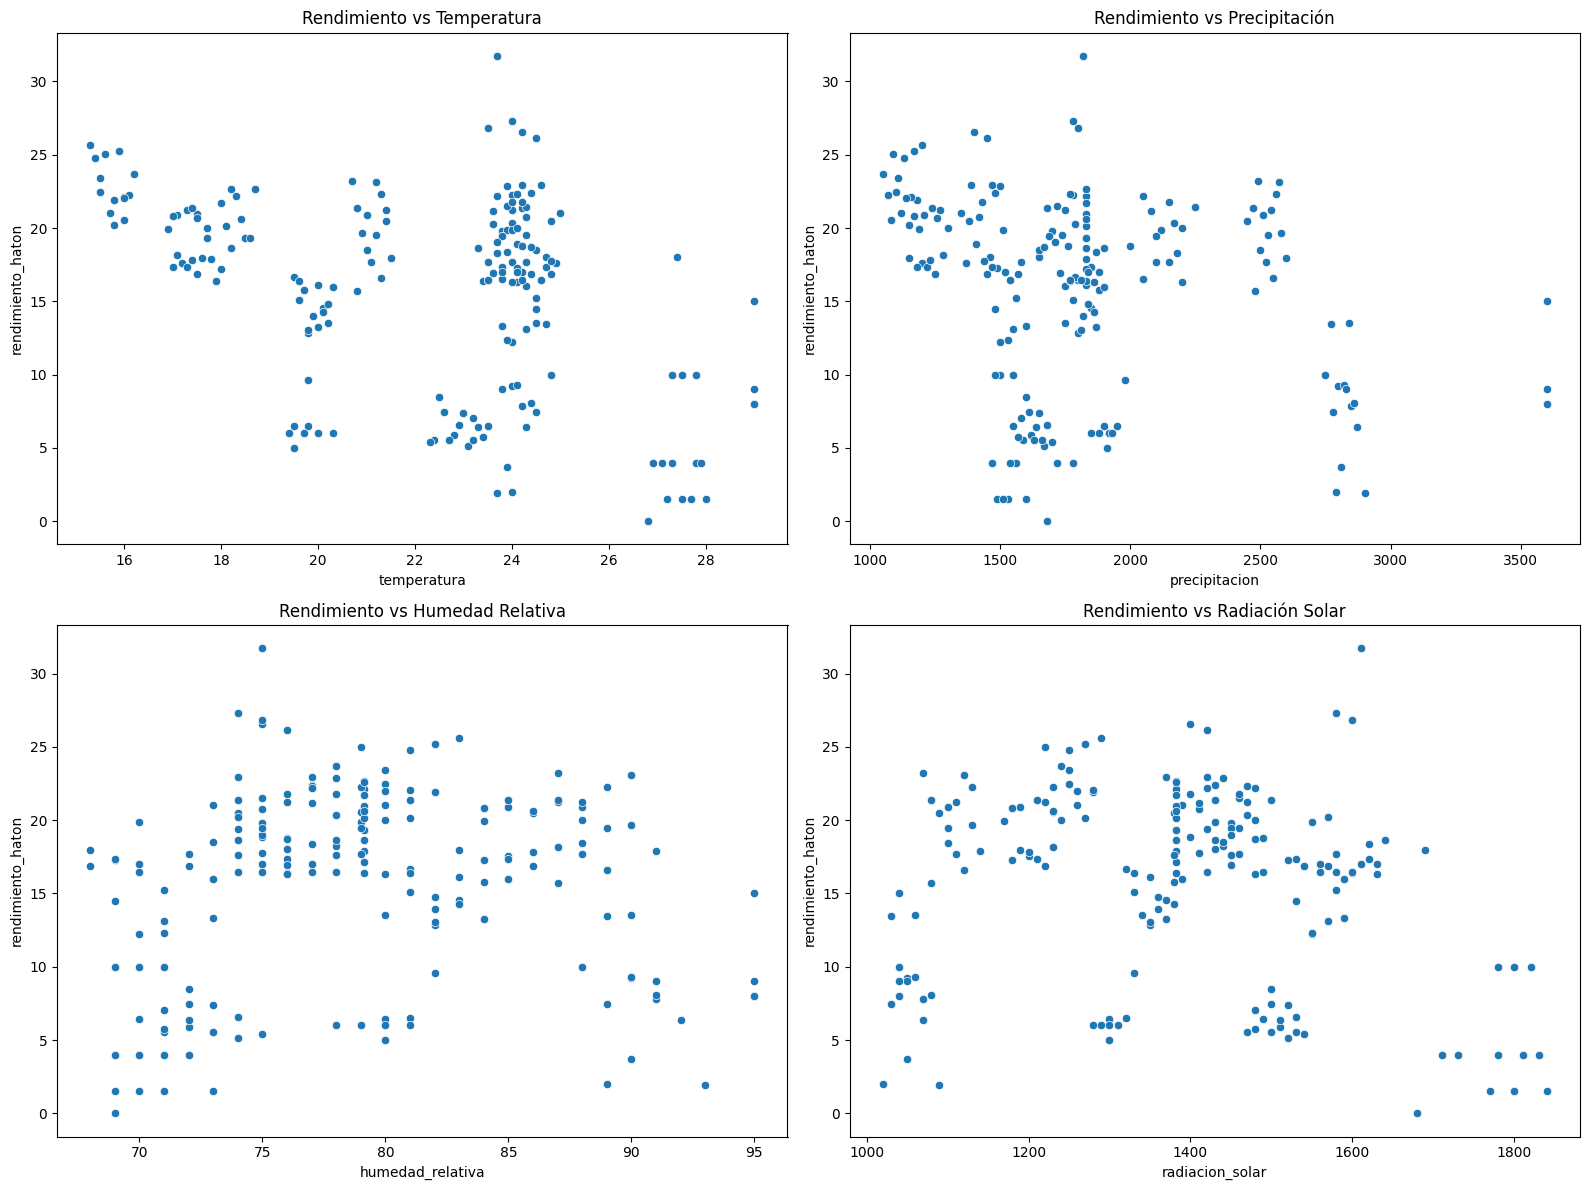

In [99]:
# Relación Rendimiento vs Variables Climáticas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(ax=axes[0, 0], data=data, x='temperatura', y='rendimiento_haton')
axes[0, 0].set_title('Rendimiento vs Temperatura')

sns.scatterplot(ax=axes[0, 1], data=data, x='precipitacion', y='rendimiento_haton')
axes[0, 1].set_title('Rendimiento vs Precipitación')

sns.scatterplot(ax=axes[1, 0], data=data, x='humedad_relativa', y='rendimiento_haton')
axes[1, 0].set_title('Rendimiento vs Humedad Relativa')

sns.scatterplot(ax=axes[1, 1], data=data, x='radiacion_solar', y='rendimiento_haton')
axes[1, 1].set_title('Rendimiento vs Radiación Solar')

plt.tight_layout()
plt.show()

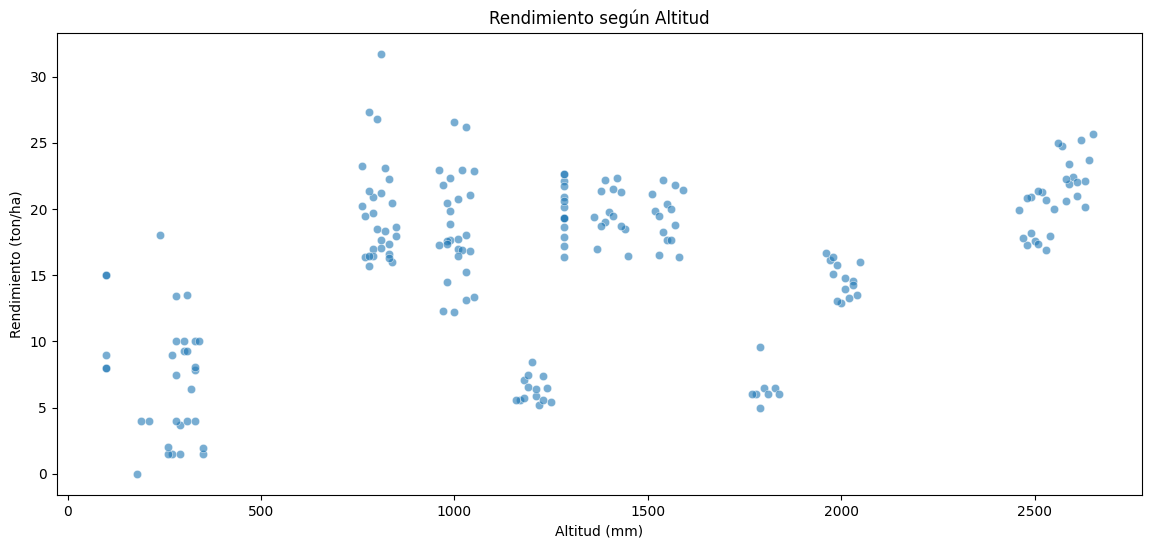

In [100]:
# Rendimiento por Altitud
plt.figure(figsize=(14, 6))
sns.scatterplot(data=data, x='altitud_mm', y='rendimiento_haton', alpha=0.6)
plt.title('Rendimiento según Altitud')
plt.xlabel('Altitud (mm)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

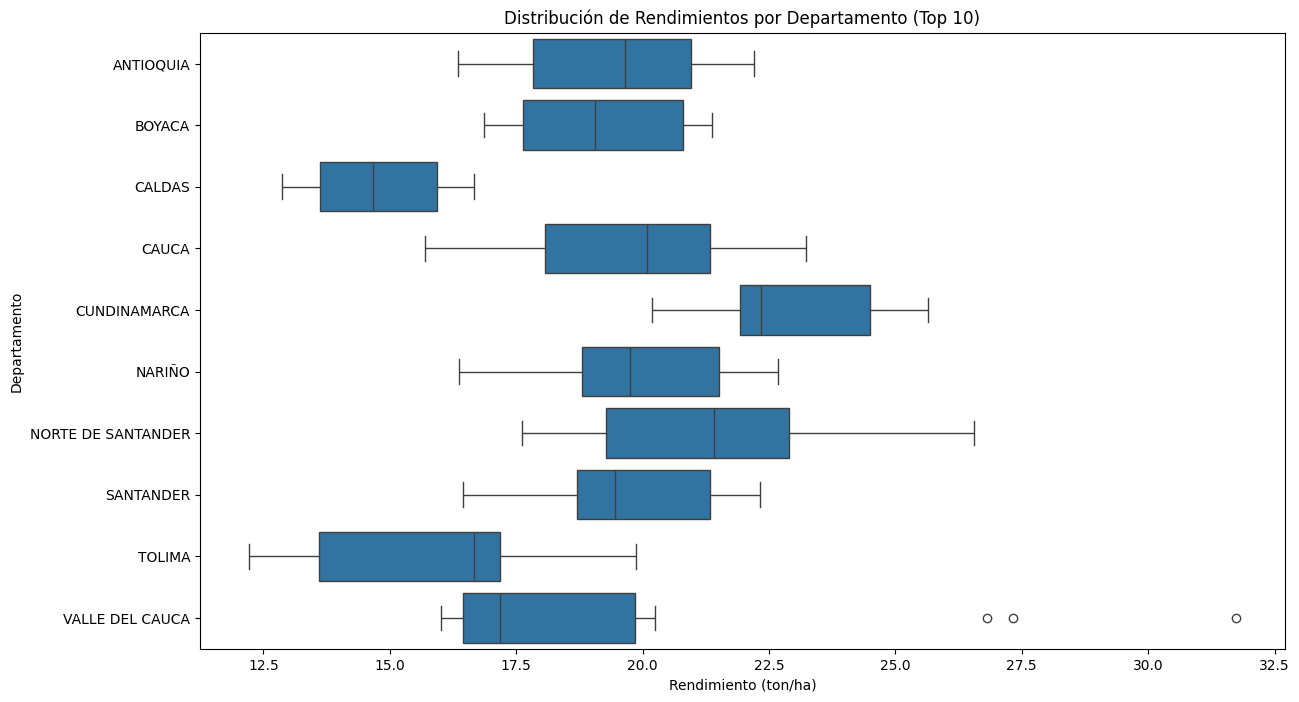

In [101]:
# Boxplot de Rendimiento por Departamento (Top 10)
top_deptos = data.groupby('departamento')['produccion_ton'].sum().nlargest(10).index
plt.figure(figsize=(14, 8))
sns.boxplot(data=data[data['departamento'].isin(top_deptos)], 
            x='rendimiento_haton', y='departamento')
plt.title('Distribución de Rendimientos por Departamento (Top 10)')
plt.xlabel('Rendimiento (ton/ha)')
plt.ylabel('Departamento')
plt.show()

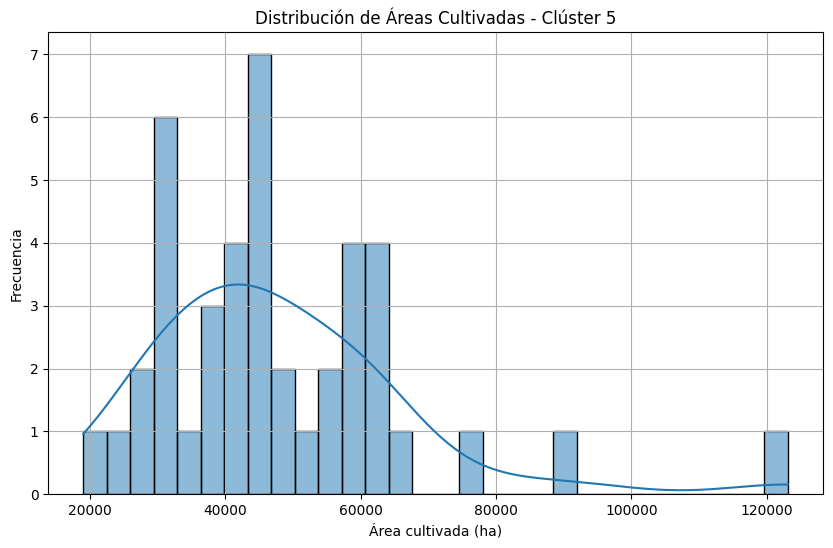

In [394]:
# Filtrar datos del clúster número 5
cluster_5 = data_cluster[data_cluster['cluster'] == 5]

# Visualizar la distribución de áreas cultivadas para el clúster 5
plt.figure(figsize=(10, 6))
sns.histplot(cluster_5['area_ha'], bins=30, kde=True)
plt.title('Distribución de Áreas Cultivadas - Clúster 5')
plt.xlabel('Área cultivada (ha)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\3298342086.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(ax=axes[0, 0], data=data, x='ano', y='temperatura', estimator='mean', ci=95)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\3298342086.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(ax=axes[0, 1], data=data, x='ano', y='precipitacion', estimator='mean', ci=95)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\3298342086.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(ax=axes[1, 0], data=data, x='ano', y='humedad_relativa', estimator='mean', ci=95)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\3298342086.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(ax=axes[1, 1], data=data, x=

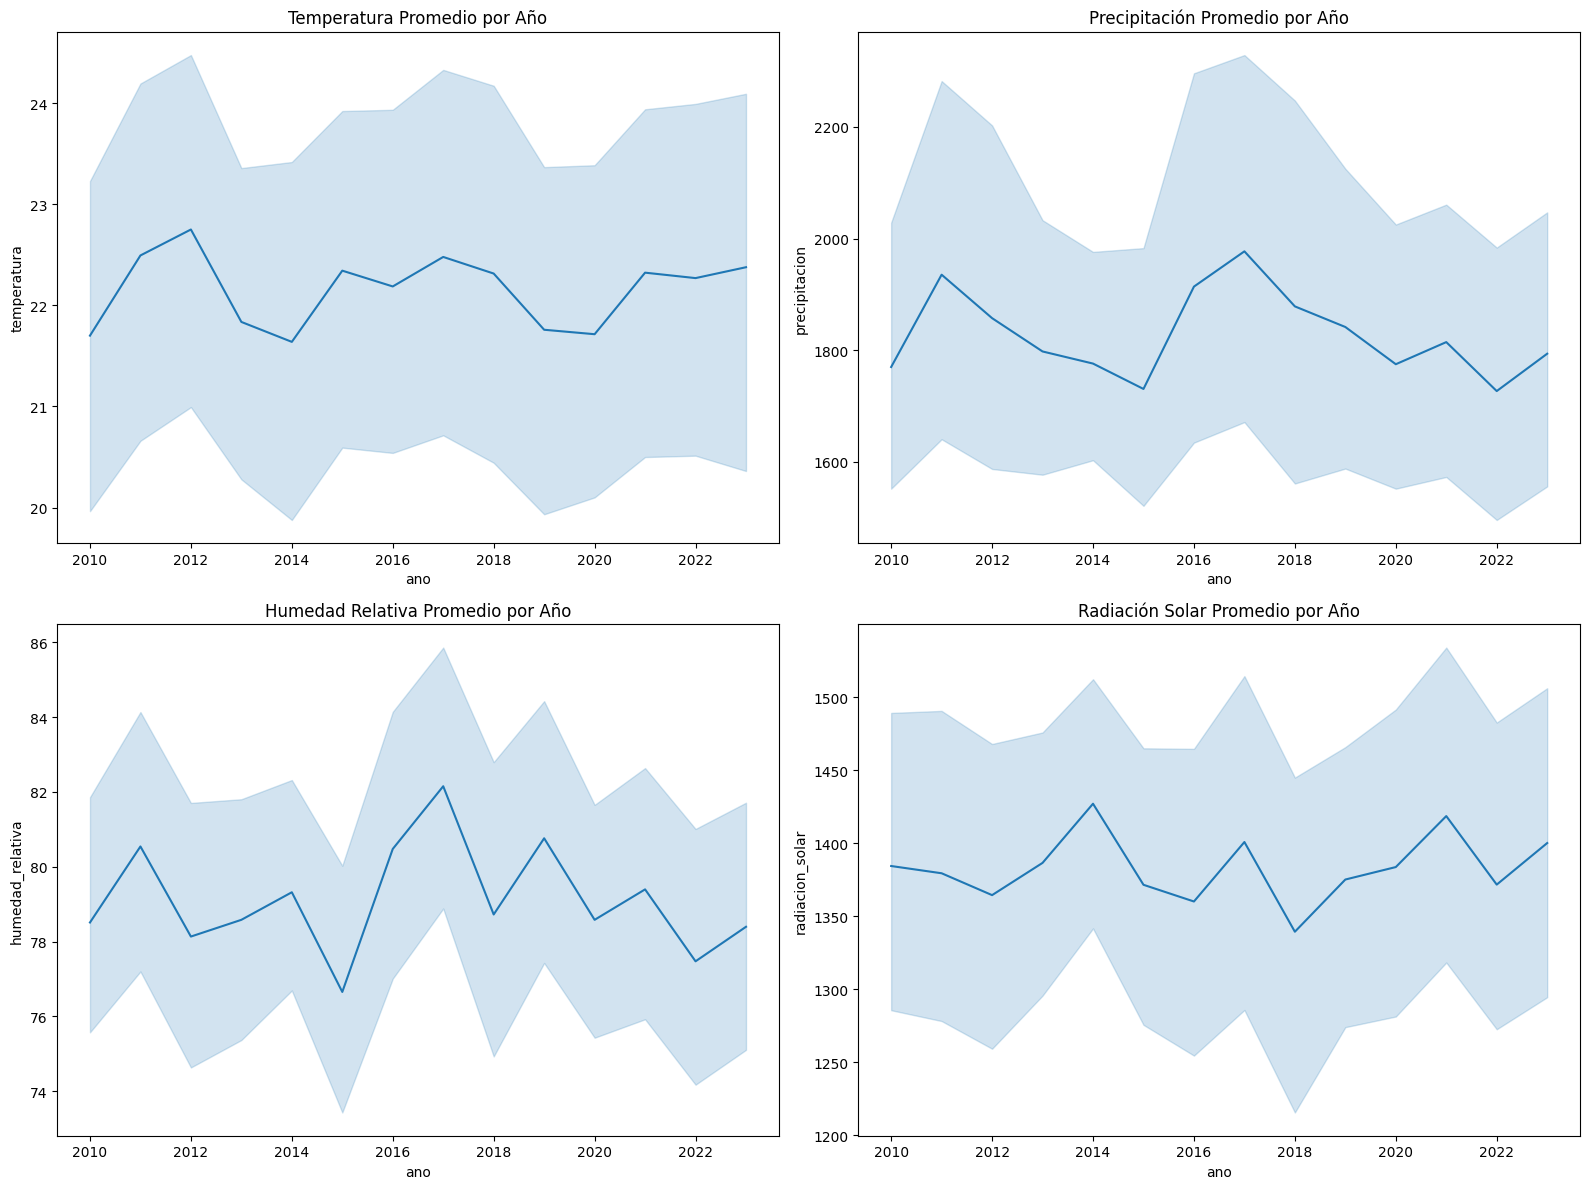

In [103]:
# Evolución de Variables Climáticas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.lineplot(ax=axes[0, 0], data=data, x='ano', y='temperatura', estimator='mean', ci=95)
axes[0, 0].set_title('Temperatura Promedio por Año')

sns.lineplot(ax=axes[0, 1], data=data, x='ano', y='precipitacion', estimator='mean', ci=95)
axes[0, 1].set_title('Precipitación Promedio por Año')

sns.lineplot(ax=axes[1, 0], data=data, x='ano', y='humedad_relativa', estimator='mean', ci=95)
axes[1, 0].set_title('Humedad Relativa Promedio por Año')

sns.lineplot(ax=axes[1, 1], data=data, x='ano', y='radiacion_solar', estimator='mean', ci=95)
axes[1, 1].set_title('Radiación Solar Promedio por Año')

plt.tight_layout()
plt.show()

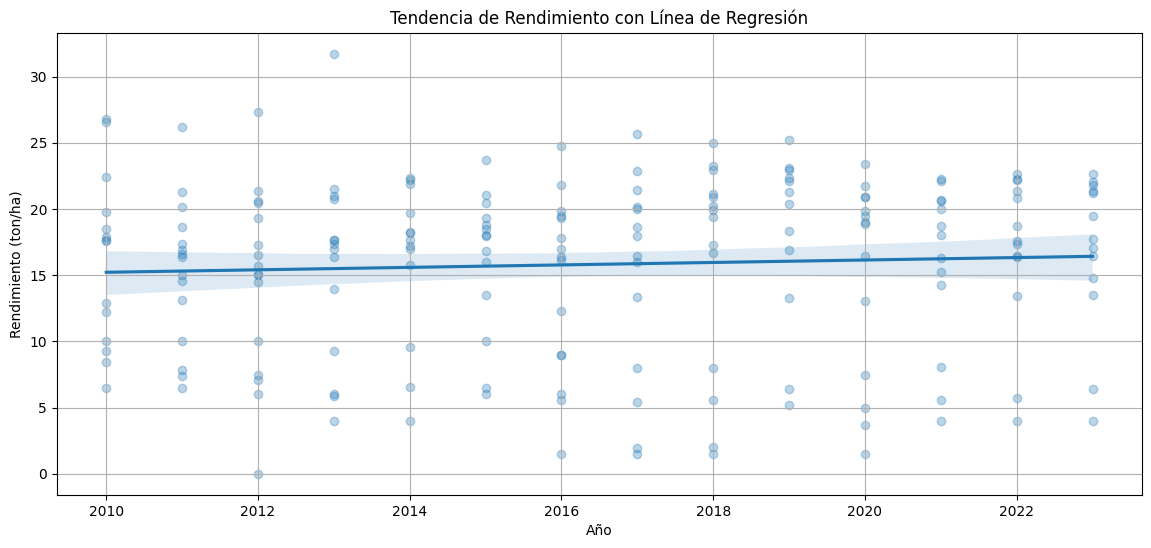

In [104]:
# Tendencia de Rendimiento con Regresión
plt.figure(figsize=(14, 6))
sns.regplot(data=data, x='ano', y='rendimiento_haton', scatter_kws={'alpha':0.3})
plt.title('Tendencia de Rendimiento con Línea de Regresión')
plt.xlabel('Año')
plt.ylabel('Rendimiento (ton/ha)')
plt.grid(True)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24544\2357455127.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data, x='ano', y='produccion_ton', estimator='sum', ci=None, ax=ax1)


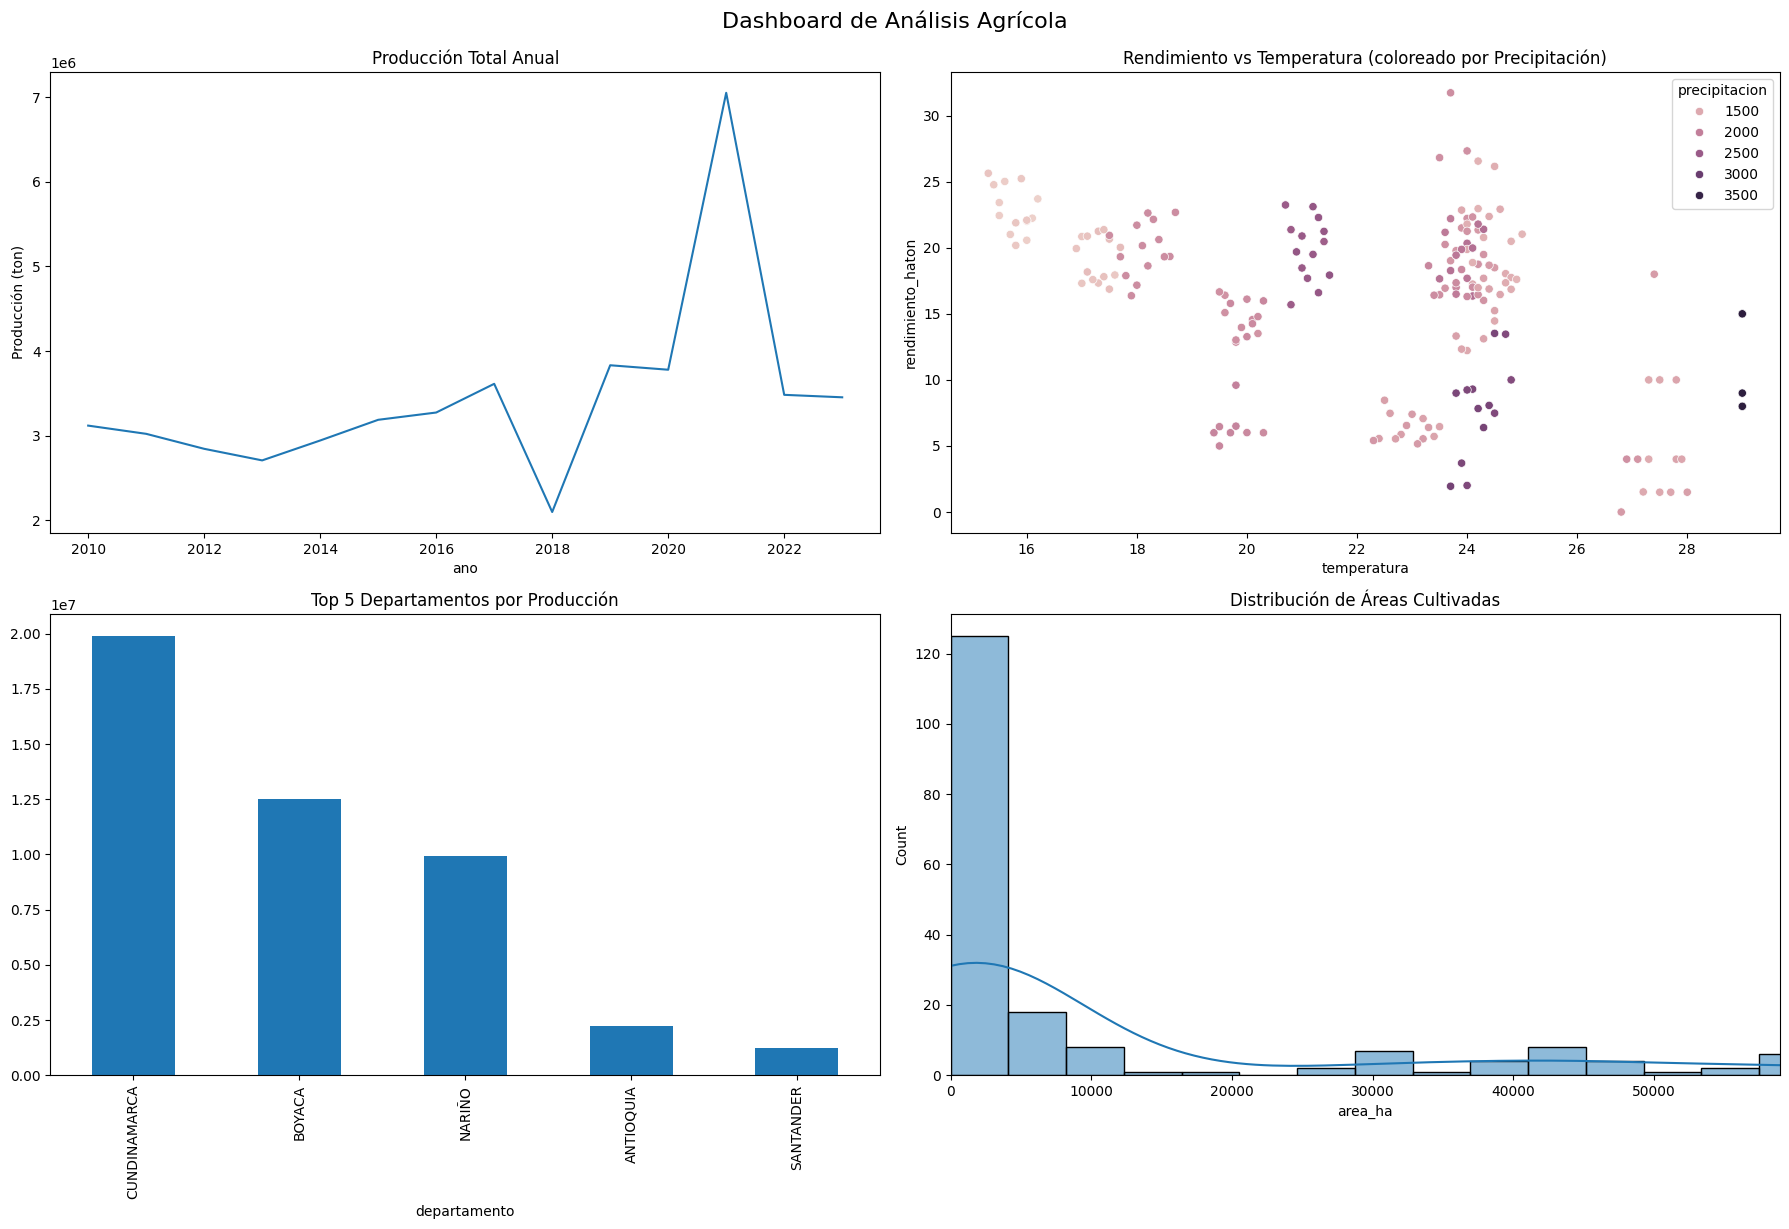

In [105]:
# Dashboard Resumen
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# Gráfico 1: Producción anual
ax1 = fig.add_subplot(gs[0, 0])
sns.lineplot(data=data, x='ano', y='produccion_ton', estimator='sum', ci=None, ax=ax1)
ax1.set_title('Producción Total Anual')
ax1.set_ylabel('Producción (ton)')

# Gráfico 2: Rendimiento vs Clima
ax2 = fig.add_subplot(gs[0, 1])
sample_size = min(1000, len(data))
sns.scatterplot(data=data.sample(sample_size, replace=False), x='temperatura', y='rendimiento_haton', hue='precipitacion', ax=ax2)
ax2.set_title('Rendimiento vs Temperatura (coloreado por Precipitación)')

# Gráfico 3: Top departamentos
ax3 = fig.add_subplot(gs[1, 0])
data.groupby('departamento')['produccion_ton'].sum().nlargest(5).plot(kind='bar', ax=ax3)
ax3.set_title('Top 5 Departamentos por Producción')

# Gráfico 4: Distribución de áreas
ax4 = fig.add_subplot(gs[1, 1])
sns.histplot(data=data, x='area_ha', bins=30, kde=True, ax=ax4)
ax4.set_title('Distribución de Áreas Cultivadas')
ax4.set_xlim(0, data['area_ha'].quantile(0.95))

plt.tight_layout()
plt.suptitle('Dashboard de Análisis Agrícola', y=1.02, fontsize=16)
plt.show()

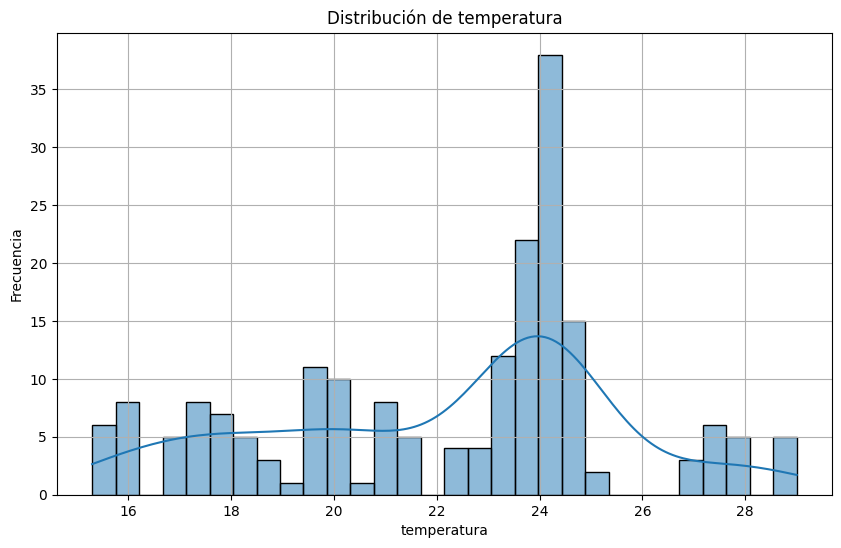

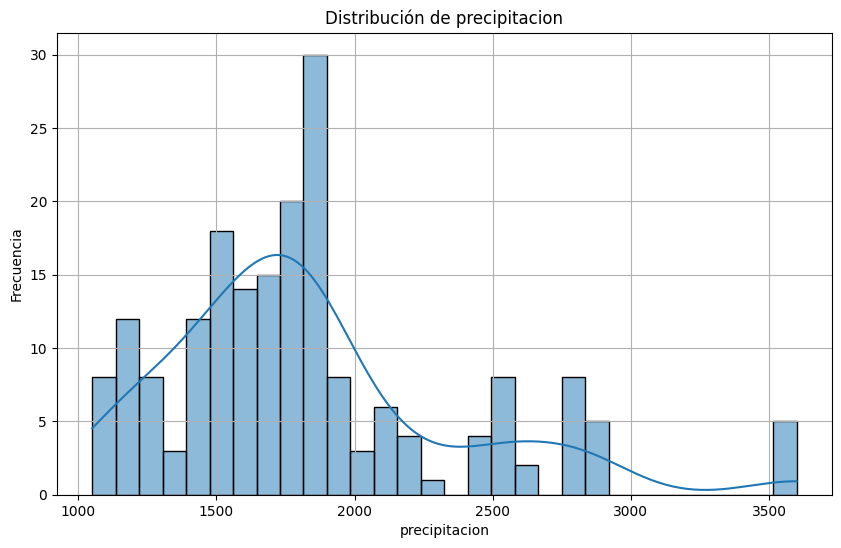

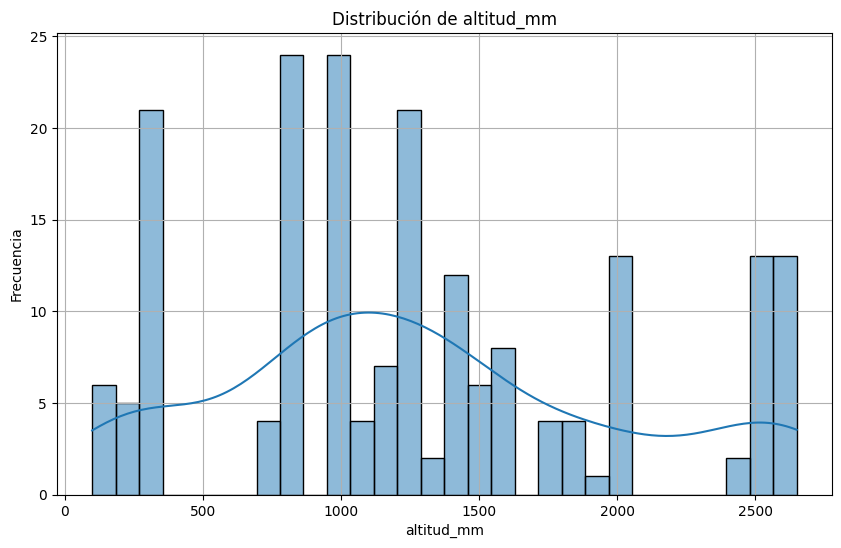

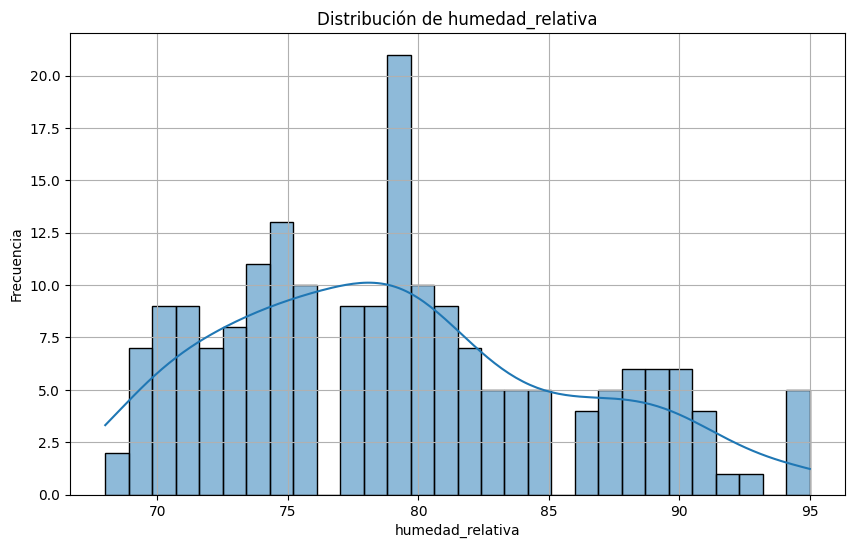

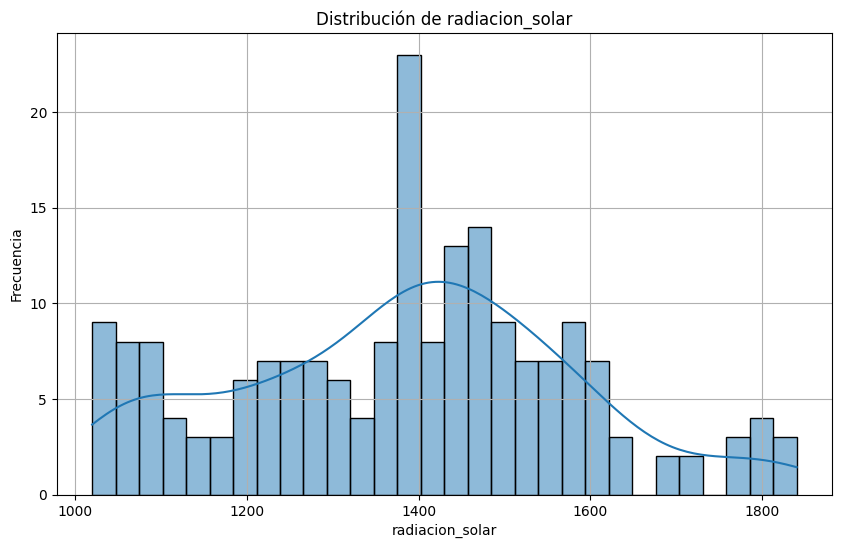

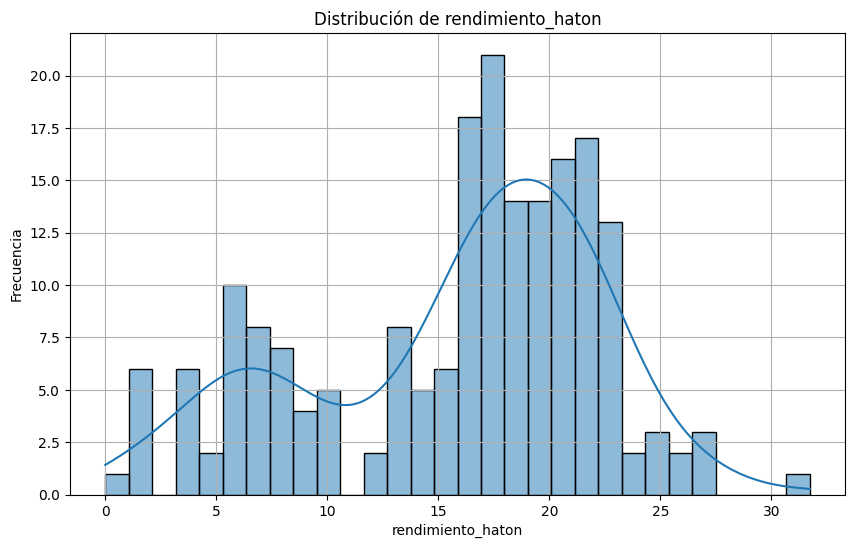

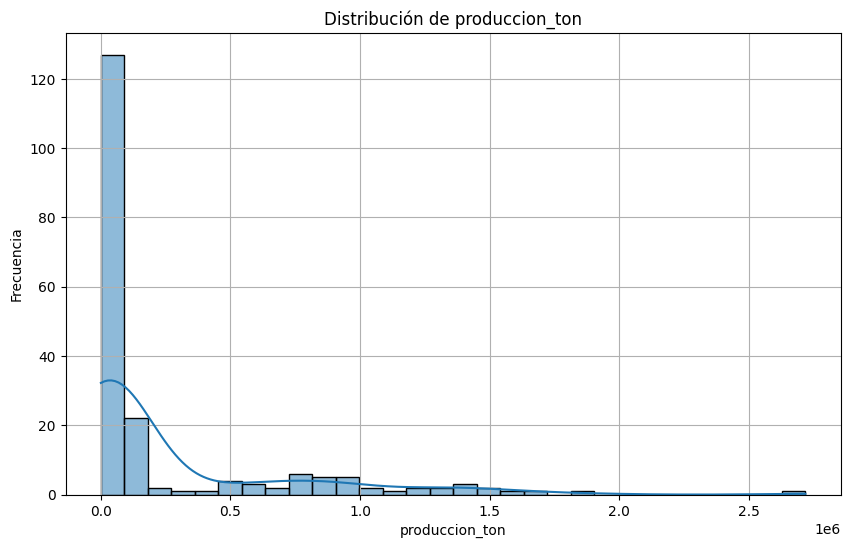

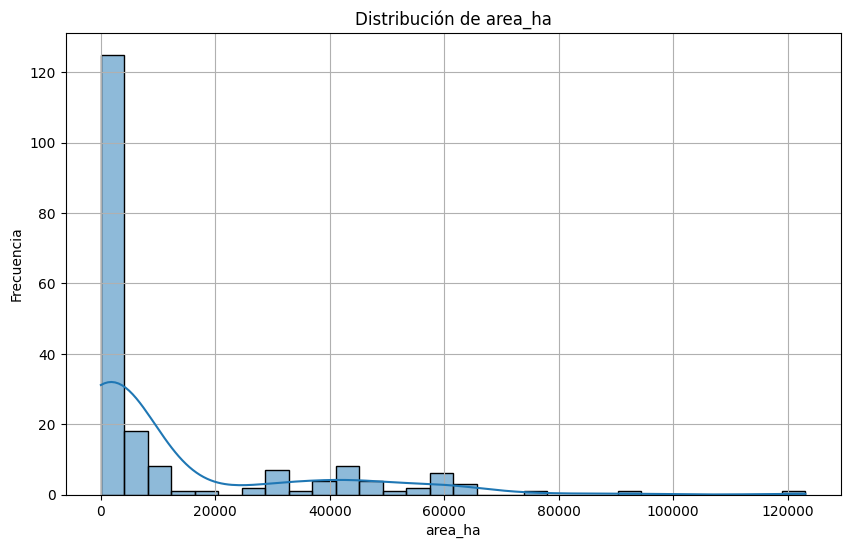

In [106]:
# Visualizar distribucción de cada variable 
import seaborn as sns
variables = ['temperatura', 'precipitacion', 'altitud_mm', 'humedad_relativa', 'radiacion_solar', 'rendimiento_haton', 'produccion_ton', 'area_ha']
for var in variables:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[var], bins=30, kde=True)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()


## 7. Modelo Supervisado - Regresión

### Modelo de regresión (KNN)

In [429]:
data.head() # Verificar el DataFrame original sin la variable de rendimiento

,ano,departamento,area_ha,temperatura,precipitacion,altitud_mm,humedad_relativa,radiacion_solar
0,2010,ANTIOQUIA,9561.80,23.5,2150.0,1550.0,78.0,1450.0
1,2010,BOYACA,46411.83,17.2,1200.0,2500.0,85.0,1200.0
2,2010,CALDAS,636.00,19.8,1800.0,2000.0,82.0,1350.0
3,2010,CASANARE,11.50,27.5,1500.0,300.0,70.0,1800.0
4,2010,CAUCA,2579.00,21.0,2500.0,800.0,88.0,1100.0


In [430]:
from sklearn.model_selection import train_test_split
# Separar variables predictoras y objetivo
X = data_normalized.drop(columns=['temperatura'])
y = data['temperatura'] # Cambiar la variable a predecir por 'produccion_ton'
#dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [431]:
# Entrenar modelo
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5) # Crear un modelo KNN con 5 vecinos
knn.fit(X_train, y_train) # Ajustar el modelo a los datos de entrenamiento

KNeighborsRegressor()

In [432]:
# Prueba y validación
from sklearn.metrics import mean_squared_error, r2_score    
# predecir y evaluar
y_pred = knn.predict(X_test) # Predecir los valores de prueba
mse = mean_squared_error(y_test, y_pred) # Calcular el error cuadrático
r2 = r2_score(y_test, y_pred) # Calcular el coeficiente de determinación R^2

Error cuadrático medio: 0.12570256410256406
Coeficiente de determinación R^2: 0.9873024677337733


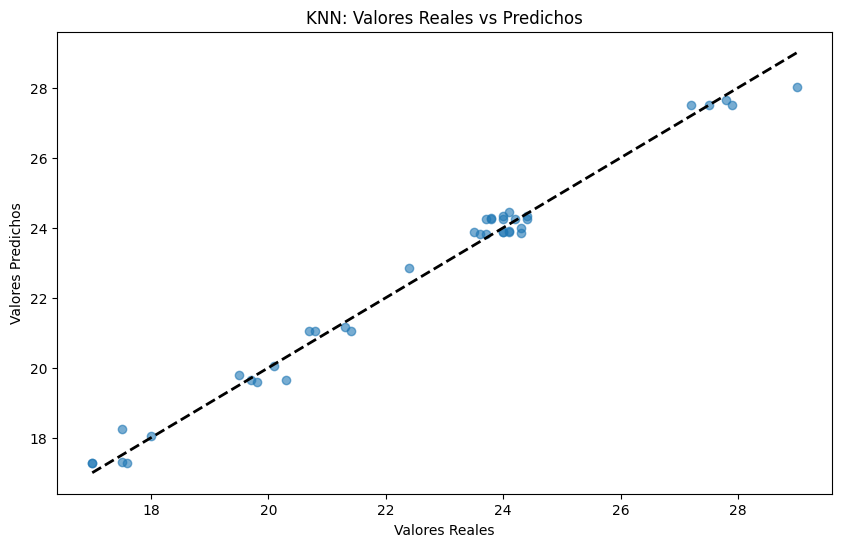

In [433]:
# imprimir resultados
print(f'Error cuadrático medio: {mse}')
print(f'Coeficiente de determinación R^2: {r2}')
# Visualización de datos reales vs predichos KNN
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('KNN: Valores Reales vs Predichos')
plt.show()

### Modelo de regresión (Random Forest)

Error cuadrático medio (Random Forest): 0.9222102307692299
Coeficiente de determinación R^2 (Random Forest): 0.9068452243195104


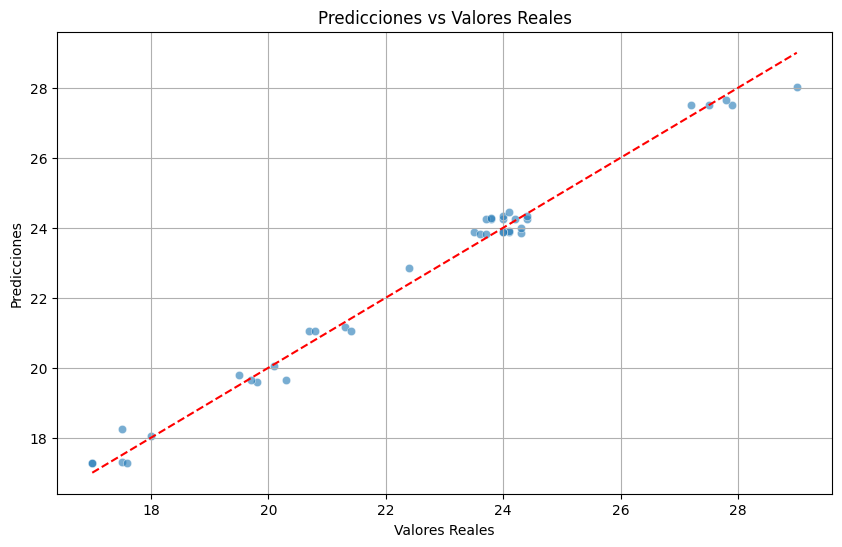

In [434]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Entrenar modelo Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predecir y evaluar
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Error cuadrático medio (Random Forest): {mse_rf}')
print(f'Coeficiente de determinación R^2 (Random Forest): {r2_rf}')

import matplotlib.pyplot as plt
import seaborn as sns   
# Visualización de datos predichos vs reales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Predicciones vs Valores Reales') 
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.grid(True)
plt.show()

### Modelo de regresión (XGBoost)

Error cuadrático medio (XGBoost): 0.7702090421968618
Coeficiente de determinación R^2 (XGBoost): 0.9221992468104733


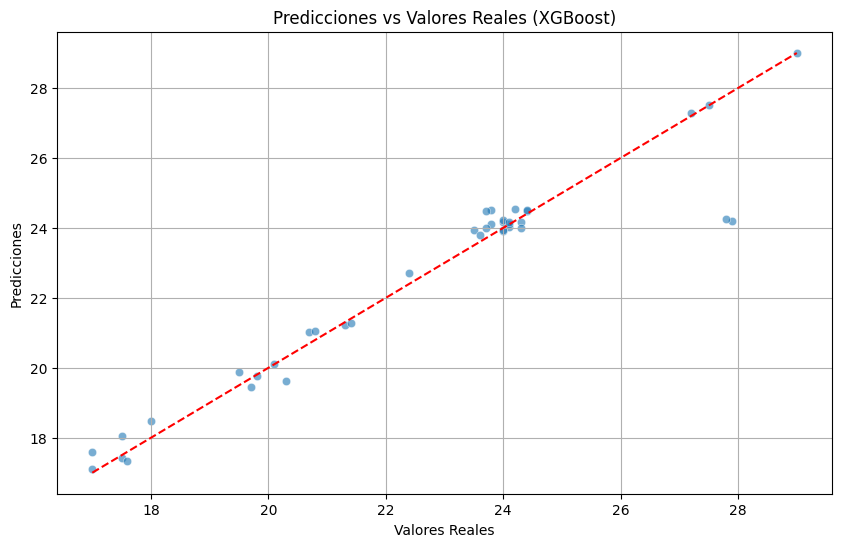

In [435]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Entrenar modelo XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# Predecir y evaluar
y_pred_xgb = xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'Error cuadrático medio (XGBoost): {mse_xgb}')
print(f'Coeficiente de determinación R^2 (XGBoost): {r2_xgb}')

# Visualización de datos predichos vs reales para XGBoost
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Predicciones vs Valores Reales (XGBoost)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.grid(True)
plt.show()

In [ ]:
La línea roja en la gráfica representa la línea de referencia donde los valores predichos por el modelo (`y_pred_xgb`) serían exactamente iguales a los valores reales (`y_test`). Es decir, es la línea de identidad (y = x).

Los puntos en la gráfica son los pares de valores reales vs. valores predichos para cada muestra del conjunto de prueba. Cada punto muestra cómo de cerca (o lejos) estuvo la predicción del modelo respecto al valor real para esa observación. Si un punto está sobre la línea roja, significa que la predicción fue perfecta para ese caso; cuanto más lejos esté un punto de la línea, mayor es el error de predicción para esa muestra.

### Clasificación datos cualitativos 

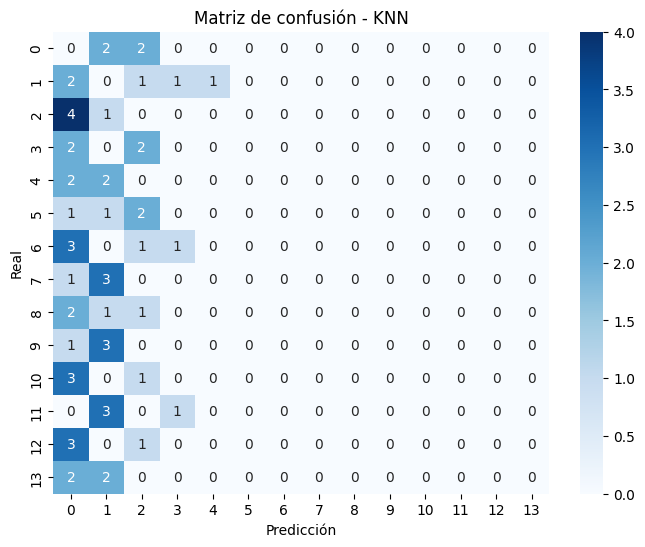

===> MÉTRICAS KNN
Accuracy: 0.0
Precision macro: 0.0
Recall macro: 0.0
F1-score macro: 0.0
AUC macro: 0.30821308321308327


c:\Users\Usuario\Desktop\tech-diplomado\entornotech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


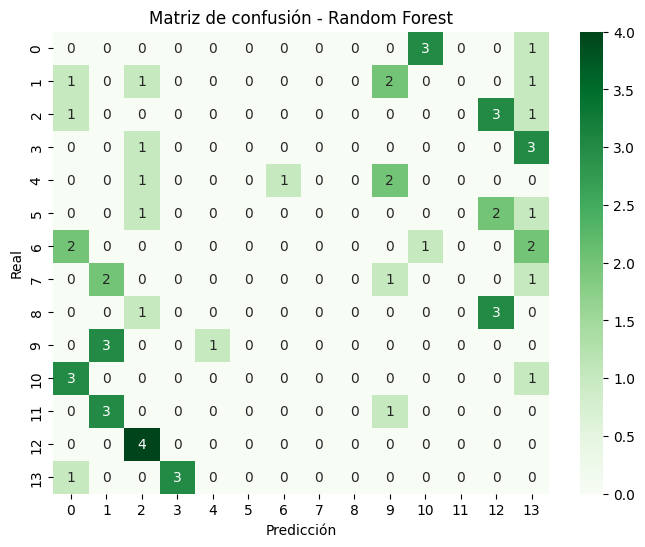

===> MÉTRICAS RANDOM FOREST
Accuracy: 0.0
Precision macro: 0.0
Recall macro: 0.0
F1-score macro: 0.0
AUC macro: 0.3116462241462242


c:\Users\Usuario\Desktop\tech-diplomado\entornotech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\Desktop\tech-diplomado\entornotech\lib\site-packages\xgboost\core.py:158: UserWarning: [14:19:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


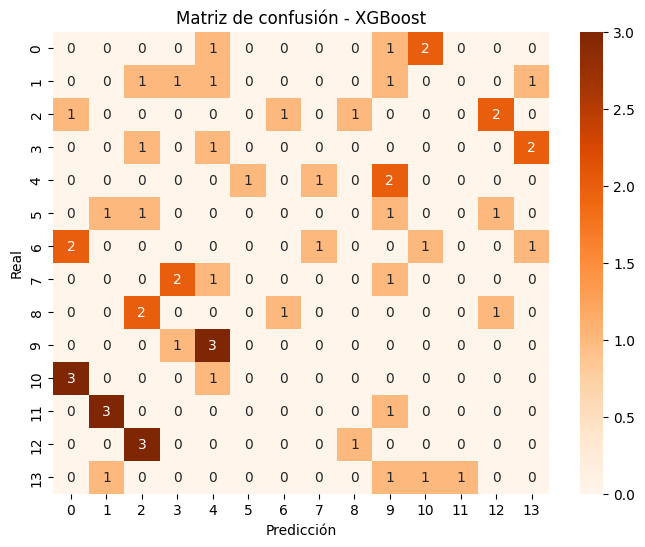

===> MÉTRICAS XGBOOST
Accuracy: 0.0
Precision macro: 0.0
Recall macro: 0.0
F1-score macro: 0.0
AUC macro: 0.3442400192400192


In [436]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Variables predictoras y objetivo
X = data.drop(columns=['ano', 'departamento'])
y = data['ano'].cat.codes

# Escalar variables
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# División de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Binarizar etiquetas para calcular AUC
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

# ------------------------------------------------
# KNN
# ------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_pred_knn_proba = knn.predict_proba(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("===> MÉTRICAS KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision macro:", precision_score(y_test, y_pred_knn, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred_knn, average='macro'))
print("F1-score macro:", f1_score(y_test, y_pred_knn, average='macro'))
try:
    auc_knn = roc_auc_score(y_test_bin, y_pred_knn_proba, multi_class="ovr", average="macro")
    print("AUC macro:", auc_knn)
except:
    print("AUC no calculable para KNN (posibles clases no balanceadas)")

# ------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("===> MÉTRICAS RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision macro:", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred_rf, average='macro'))
print("F1-score macro:", f1_score(y_test, y_pred_rf, average='macro'))
auc_rf = roc_auc_score(y_test_bin, y_pred_rf_proba, multi_class="ovr", average="macro")
print("AUC macro:", auc_rf)

# ------------------------------------------------
# XGBOOST
# ------------------------------------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_proba = xgb.predict_proba(X_test)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("Matriz de confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

print("===> MÉTRICAS XGBOOST")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision macro:", precision_score(y_test, y_pred_xgb, average='macro'))
print("Recall macro:", recall_score(y_test, y_pred_xgb, average='macro'))
print("F1-score macro:", f1_score(y_test, y_pred_xgb, average='macro'))
auc_xgb = roc_auc_score(y_test_bin, y_pred_xgb_proba, multi_class="ovr", average="macro")
print("AUC macro:", auc_xgb)


## Redes Neuronales

c:\Users\Usuario\Desktop\tech-diplomado\entornotech\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 515.0795 - mean_absolute_error: 22.4594 - val_loss: 458.0245 - val_mean_absolute_error: 21.1056
Epoch 2/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 505.0170 - mean_absolute_error: 22.2301 - val_loss: 450.3702 - val_mean_absolute_error: 20.9230
Epoch 3/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 506.0547 - mean_absolute_error: 22.2296 - val_loss: 443.4325 - val_mean_absolute_error: 20.7556
Epoch 4/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 496.9067 - mean_absolute_error: 22.0228 - val_loss: 436.9568 - val_mean_absolute_error: 20.5972
Epoch 5/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 492.0075 - mean_absolute_error: 21.9322 - val_loss: 430.3017 - val_mean_absolute_error: 20.4338
Epoch 6/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 485.0882 - mean_absolute_error: 21.7961 - val_loss: 423.1091 - val_mean_absolute_error: 20.2570
Epoch 7/65
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 475.8480 - mean_absolute

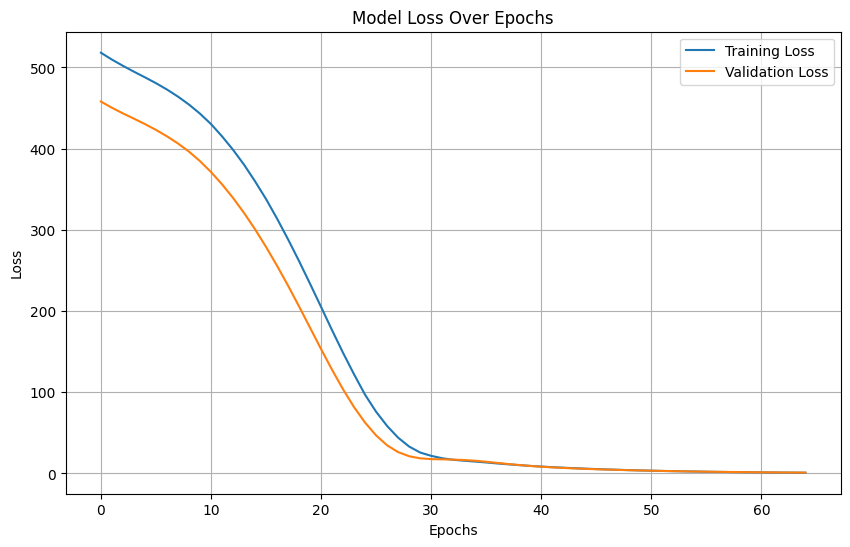

In [442]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Carga del dataset
norma_df = data_normalized.copy()  # Usar el DataFrame normalizado
imp_df = data.copy()  # Usar el DataFrame original para la variable objetivo
# 2. Preparación de datos
X = norma_df.drop(columns=['temperatura'])  # todas las columnas excepto la target
y = imp_df['temperatura']  # variable objetivo
# 3. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5. Definición del modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # una neurona de salida para regresión
])

# 6. Compilación
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)
# 7. Resumen de la arquitectura
model.summary()
# 8. Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=65,
    batch_size=32,
    verbose=1
)


# 9. Evaluación en el conjunto de prueba
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida (MSE) en test: {loss:.4f}")
print(f"Error absoluto medio (MAE) en test: {mae:.4f}")


# Plotting the training loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Refinamiento del modelo - KNN

Mejores hiperparámetros encontrados: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Error cuadrático medio (MSE): 0.0867
Coeficiente de determinación R^2: 0.9912
R^2 promedio validación cruzada (10-fold): 0.9916 ± 0.0062


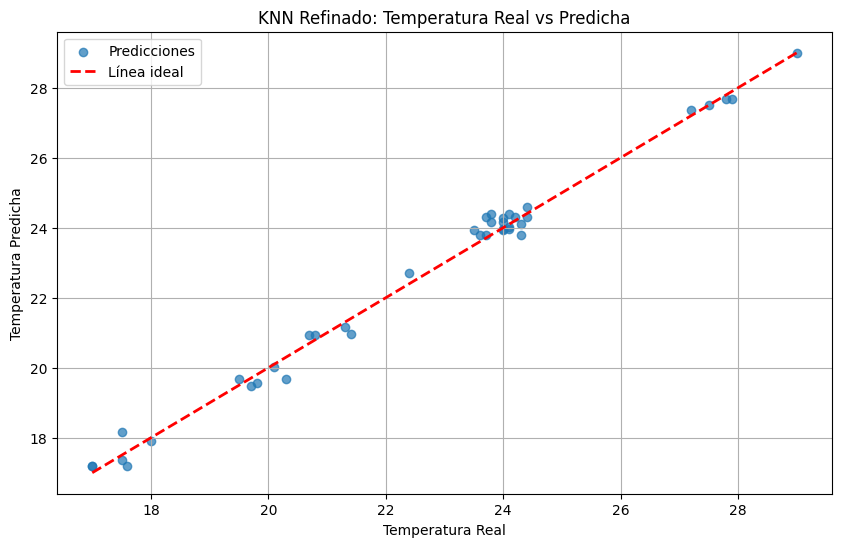

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import joblib  # <-- Agregado para guardar el modelo

# Refinamiento del modelo KNN para regresión de temperatura
# ---------------------------------------------------------
# 1. Importar librerías necesarias

# 2. Selección de variables predictoras y objetivo
# Usamos el DataFrame normalizado y la variable objetivo original
X = data_normalized.drop(columns=['temperatura'])
y = data['temperatura']

# 3. División en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Búsqueda de hiperparámetros óptimos usando GridSearchCV
# Probamos diferentes valores de k y pesos
param_grid = {
    'n_neighbors': list(range(3, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan y Euclidiana
}
knn = KNeighborsRegressor()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# 5. Entrenamiento del modelo óptimo
best_knn = grid.best_estimator_
best_knn.fit(X_train, y_train)

# Guardar el modelo entrenado
joblib.dump(best_knn, '../Modelos/modelo_knn_temperatura.pkl')
joblib.dump(scaler, '../Modelos/scaler_knn_temperatura.pkl')  # Guardar el scaler también

# 6. Evaluación del modelo
y_pred = best_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mejores hiperparámetros encontrados:", grid.best_params_)
print(f'Error cuadrático medio (MSE): {mse:.4f}')
print(f'Coeficiente de determinación R^2: {r2:.4f}')

# 7. Validación cruzada para robustez
cv_scores = cross_val_score(best_knn, X, y, cv=10, scoring='r2')
print(f'R^2 promedio validación cruzada (10-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# 8. Visualización: Valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
plt.xlabel('Temperatura Real')
plt.ylabel('Temperatura Predicha')
plt.title('KNN Refinado: Temperatura Real vs Predicha')
plt.legend()
plt.grid(True)
plt.show()

In [438]:
with open("columnas_data_normalized.txt", "w") as f:
    for col in data_normalized.columns:
        f.write(col + "\n")
